# TITLE AND PROJECT OBJECTIVE 
## OWID Energy Portfolio — Long-Run Energy Transition Analysis

This notebook analyzes long-run energy trends using Python, pandas, and matplotlib, with a focus on OECD vs Non-OECD comparisons, Canada vs the world, and Canada vs selected peer countries. The goal is to identify how energy demand, electricity mix, carbon intensity, and renewables have changed over time, and what those trends suggest about future energy-system growth.

## EXECUTIVE SUMMARY 
This project examines how energy systems have evolved over time across major country groupings and peer comparisons. The analysis shows that Non-OECD total primary energy demand has grown much faster than OECD demand, while OECD countries still maintain higher per-capita energy use. In electricity, OECD carbon intensity falls more sharply and fossil vs low-carbon generation moves much closer to parity than in Non-OECD systems.

At the primary-energy level, renewables rise globally, but Canada’s overall system mix changes more slowly than the world average. Across the historical trends reviewed here, wind and solar show the strongest evidence of continued growth, while coal generally loses share most clearly in OECD electricity systems. These findings support a broader conclusion: electricity is decarbonizing faster than the wider primary-energy system, where transport, heating, and industrial energy use slow the pace of transition.

## METHOD / READER NOTES

- **OECD** = Organisation for Economic Co-operation and Development; **Non-OECD** = countries outside the OECD grouping used in this project.
- OECD and Non-OECD were used here as analytical groupings constructed from country-level data.
- Some comparisons were restricted to periods with more stable coverage or lower missingness.
- Where visible breaks likely reflect reporting or coverage shifts rather than true one-year structural change, this is noted in the analysis.
- Figures are presented as the final cleaned outputs used to support the written interpretation in each section.

# QUESTION 1A. How has global primary energy consumption evolved over time, and how does this differ between OECD and Non-OECD regions?

### WHY DOES THIS QUESTION MATTER?
Understanding how energy demand changes across major regions helps explain where future infrastructure needs, emissions pressures, and transition challenges are likely to be concentrated. Comparing OECD and Non-OECD trends also shows whether energy-system change is happening under similar conditions or whether different growth, development, and access patterns are shaping the transition in different ways.

## DATA LOADING

The analysis begins with the OWID energy dataset, which contains country-level observations across energy consumption, energy shares, electricity mix, emissions, and related indicators.

In [2]:
import pandas as pd

df = pd.read_csv('owid-energy-data.csv')


## DATA OVERVIEW

The raw dataset is structured as country-year observations and includes variables related to primary energy consumption, electricity mix, population, GDP, and emissions. The notebook uses the subset of fields needed for each question rather than every available column in the source file.

In [3]:
#inspecting number of rows/observations and columns 
df.shape

(23195, 130)

## GROUPING LOGIC

The original dataset does not provide OECD and Non-OECD as ready-made analytical groups for this comparison. To support region-level analysis in Q1–Q4, a grouping variable is created from country ISO codes using an OECD membership list.

In [4]:
#including OECD(Organisation for Economic Co-operation and Development) countries to the list 

oecd_countries = [
    "AUS","AUT","BEL","CAN","CHL","COL","CRI","CZE","DNK","EST",
    "FIN","FRA","DEU","GRC","HUN","ISL","IRL","ISR","ITA","JPN",
    "KOR","LVA","LTU","LUX","MEX","NLD","NZL","NOR","POL","PRT",
    "SVK","SVN","ESP","SWE","CHE","TUR","GBR","USA"
]

#creating an analytical grouping variable for OECD vs Non-OECD comparisons

df["region_type"] = df["iso_code"].apply(
    lambda x: "OECD" if x in oecd_countries else "Non-OECD"
)

In [5]:
df[["country", "iso_code", "region_type"]].head()

,country,iso_code,region_type
0,ASEAN (Ember),NaN,Non-OECD
1,ASEAN (Ember),NaN,Non-OECD
2,ASEAN (Ember),NaN,Non-OECD
3,ASEAN (Ember),NaN,Non-OECD
4,ASEAN (Ember),NaN,Non-OECD


## COVERAGE CHECK AND COMPARISON WINDOW

To avoid misleading regional totals, the OECD and Non-OECD comparison is restricted to the latest period with stable coverage in both groups. This step checks whether the final years in the dataset remain comparable before plotting regional aggregates.

In [6]:
# keeping only what we need
tmp = df[df["region_type"].isin(["OECD", "Non-OECD"]) & df["year"].ge(1965)].copy()

# finding out how many rows (countries) contribute to the total each year in each region?
coverage = (
    tmp.dropna(subset=["primary_energy_consumption"])
       .groupby(["year", "region_type"])["primary_energy_consumption"]
       .count()
       .unstack()
)

# picking the last year where both regions still have a "near-max" coverage
# (95% is a reasonable cutoff)
max_cov = coverage.max()
good_years = coverage[(coverage["OECD"] >= 0.95 * max_cov["OECD"]) &
                      (coverage["Non-OECD"] >= 0.95 * max_cov["Non-OECD"])]

end_year = int(good_years.index.max())
coverage.tail(5)

region_type,Non-OECD,OECD
year,,
2020,232,38
2021,232,38
2022,232,38
2023,232,38
2024,74,37


**Data coverage note:** 2024 values are excluded from the regional totals because Non-OECD coverage drops sharply (from about 232 reporting countries in 2023 to 74 in 2024), which would artificially depress aggregate totals. The Q1A comparison therefore uses 1965–2023 as the stable coverage window.

## Q1A ANALYSIS SETUP

Using the stable comparison window identified above, the dataset is filtered to the fields needed for regional aggregation of total primary energy consumption.

In [7]:
# selecting columns required for this analysis 
q1_columns = ["country", "year", "iso_code", "region_type", "primary_energy_consumption"]

# restricting analysis from 1965 upward due to sparse data from previous years
total_energy_df = df[
    df["region_type"].isin(["OECD", "Non-OECD"]) &
    df["year"].between(1965, end_year)
][q1_columns].copy()


In [8]:
total_energy_trend = (
    total_energy_df.groupby(["year", "region_type"])["primary_energy_consumption"].sum().reset_index()
    )

In [9]:
#pivoting to make visualization easier
total_energy_pivot = total_energy_trend.pivot(
    index = "year", 
    columns = "region_type", 
    values = "primary_energy_consumption"
)

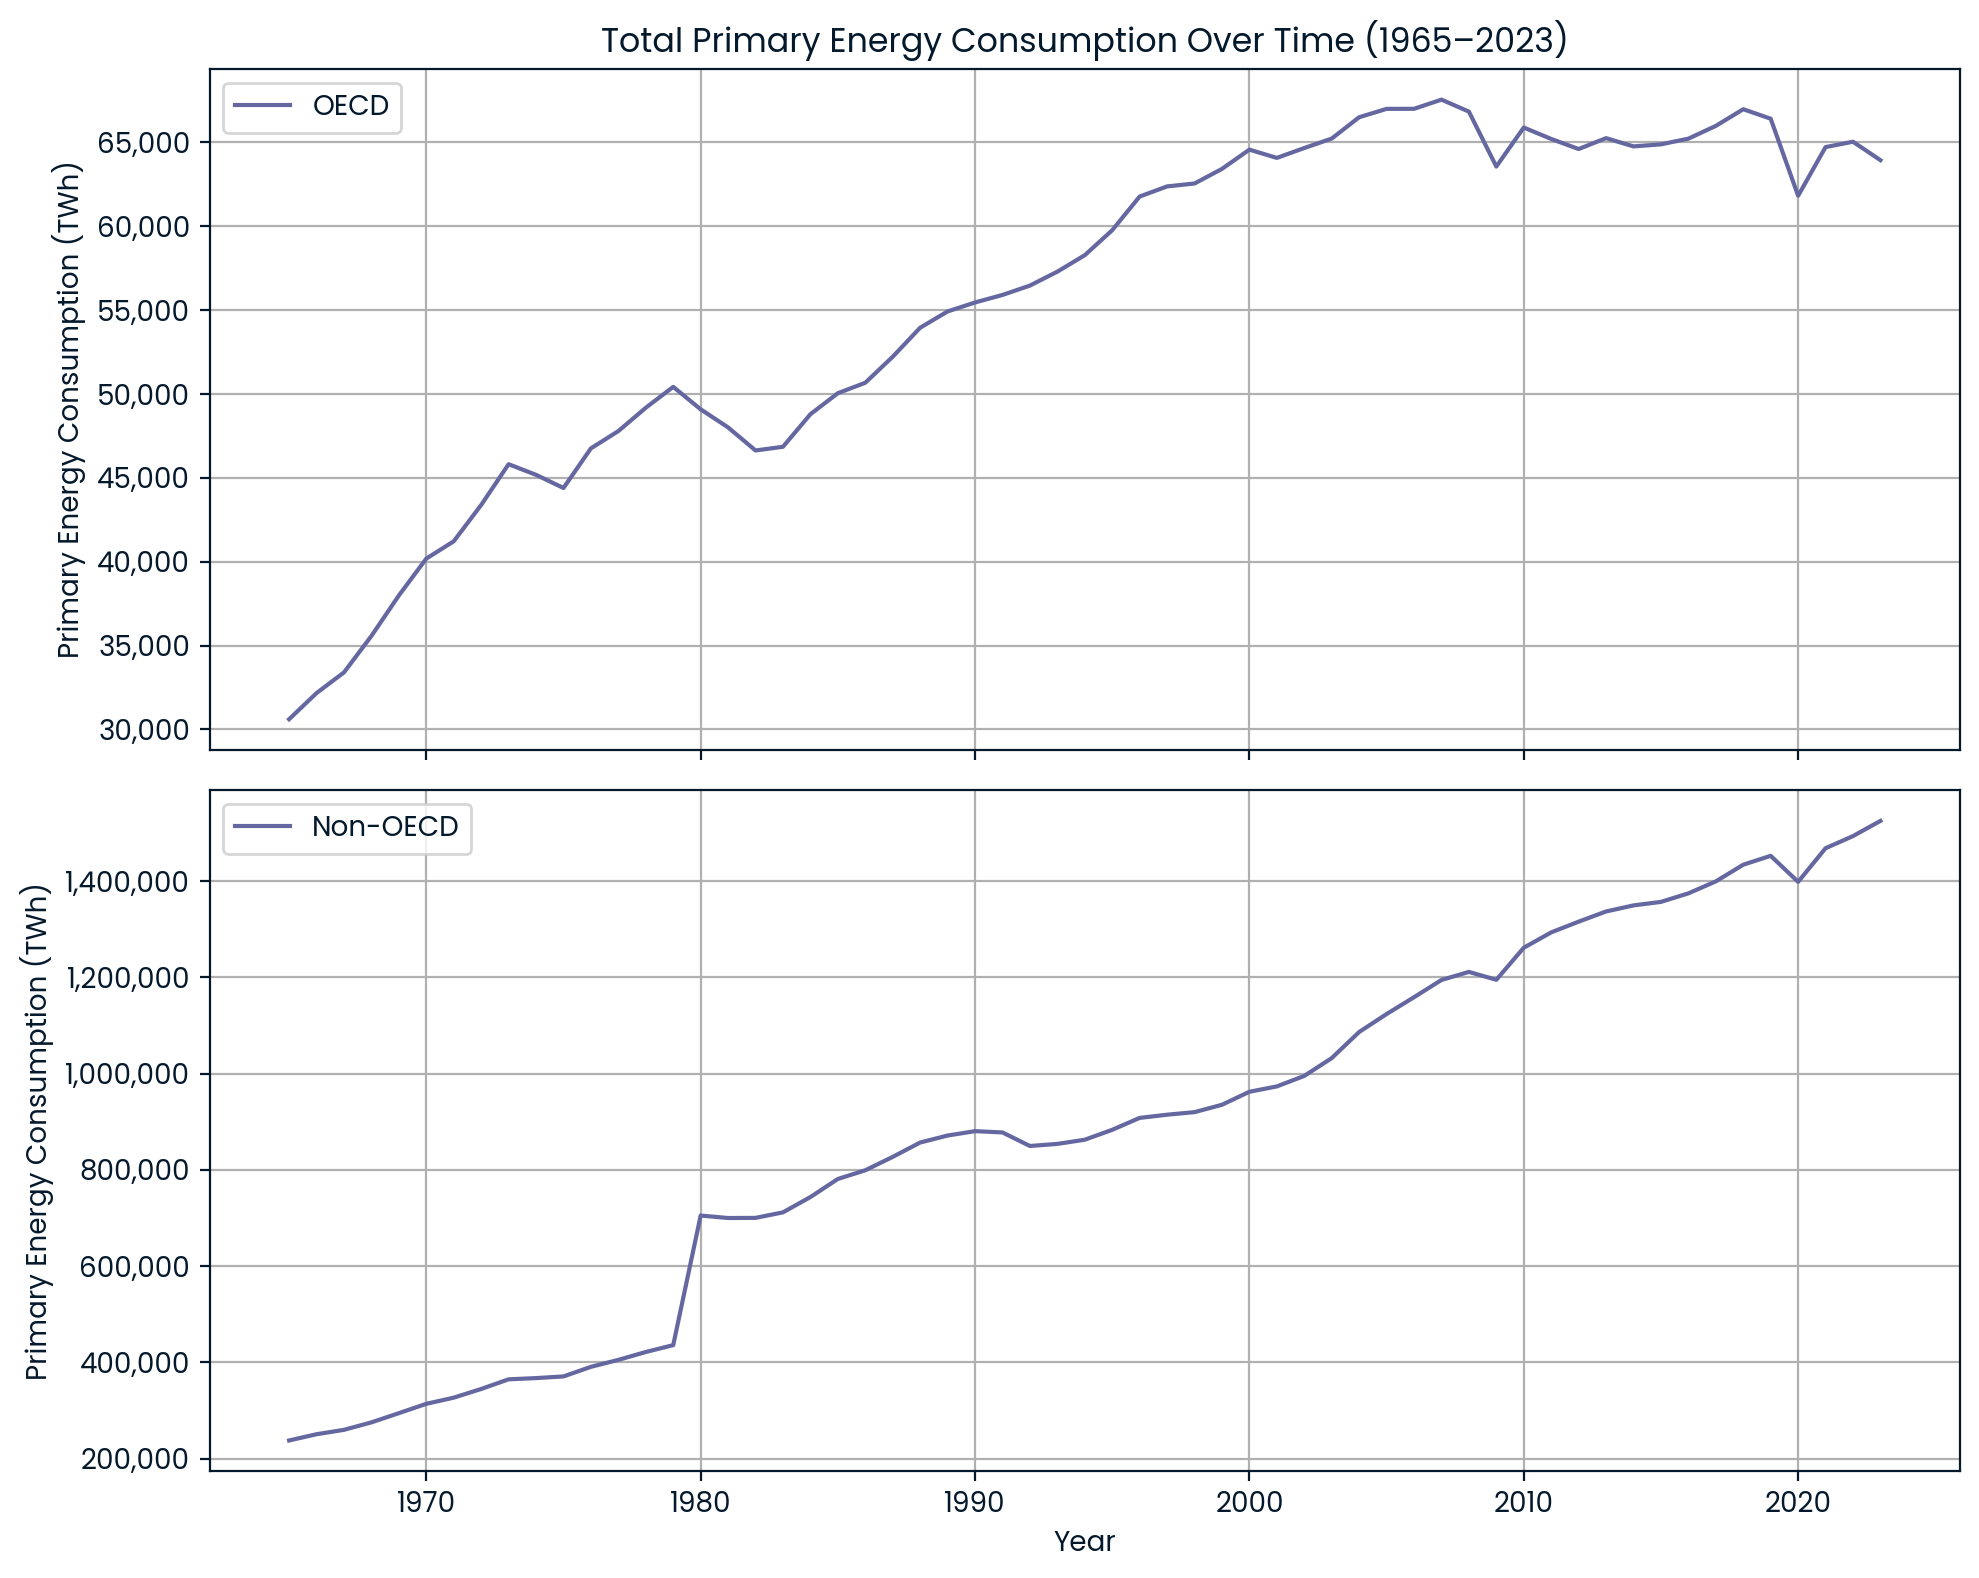

In [10]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)

# --- Top: OECD ---
axes[0].plot(total_energy_pivot.index, total_energy_pivot["OECD"], label="OECD")
axes[0].set_title("Total Primary Energy Consumption Over Time (1965–2023)")
axes[0].set_ylabel("Primary Energy Consumption (TWh)")
axes[0].yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
axes[0].grid(True)
axes[0].legend()

# --- Bottom: Non-OECD ---
axes[1].plot(total_energy_pivot.index, total_energy_pivot["Non-OECD"], label="Non-OECD")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Primary Energy Consumption (TWh)")
axes[1].yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.savefig("q1a_oecd_non_oecd_total_primary_energy.png", dpi=300, bbox_inches="tight")
plt.show()

**Note:** Analysis uses 1965–2023/24 where both OECD and Non-OECD series have consistent coverage.

### Interpretation

From 1965 onward, Non-OECD primary energy consumption rises strongly and accelerates further after 2000, consistent with expanding energy demand as populations, incomes, industrial activity, and urbanization increase. OECD primary energy consumption also rises over time, but more gradually, and it broadly plateaus in the later period rather than continuing the earlier pace of growth. This suggests a more mature energy-demand profile shaped by efficiency gains, slower population growth, and a shift toward less energy-intensive economic activity.

Taken together, these trends show that total energy-demand growth has been much more dynamic in Non-OECD regions than in OECD regions over the long run.

# 1B. How has per-capita energy consumption evolved over time in OECD vs Non-OECD 

### WHY DOES THIS QUESTION MATTER?

Total energy demand shows the scale of energy use, but per-capita energy consumption shows intensity. Comparing OECD and Non-OECD trends on a per-person basis helps clarify whether differences in total demand are driven mainly by population size or by how energy-intensive each region is on average.

In [11]:
# restricting to OECD and Non-OECD observations from 1965 onward
tmp = df[df["region_type"].isin(["OECD", "Non-OECD"]) & df["year"].ge(1965)].copy()

# count reporting countries by year and region for energy_per_capita
coverage = (
    tmp.dropna(subset=["primary_energy_consumption"])
       .groupby(["year", "region_type"])["energy_per_capita"]
       .count()
       .unstack()
)

# using the latest year with near-max coverage in both groups
# (95% is a reasonable cutoff)
max_cov = coverage.max()
good_years = coverage[(coverage["OECD"] >= 0.95 * max_cov["OECD"]) &
                      (coverage["Non-OECD"] >= 0.95 * max_cov["Non-OECD"])]

end_year = int(good_years.index.max())
coverage.tail(5)
             



region_type,Non-OECD,OECD
year,,
2020,191,38
2021,191,38
2022,191,38
2023,191,38
2024,53,37


**Data coverage note:** 2024 values are excluded from the regional totals because Non-OECD coverage drops sharply (from 191 reporting countries in 2023 to 53 in 2024), which would artificially depress the aggregate totals. The analysis therefore uses 1965–2023 as the consistent comparison window.

## Q1B ANALYSIS SETUP

Using the stable comparison window identified above, the dataset is filtered to the fields needed for OECD vs Non-OECD per-capita energy analysis.

In [12]:
#selecting columns required for this analysis 
q1_capita_columns = ["country", "year", "region_type", "energy_per_capita"]
per_capita_trend = df[
    df["region_type"].isin(["OECD", "Non-OECD"]) &
    df["year"].between(1965, end_year)
][q1_capita_columns].copy()

In [13]:

per_capita_grouped = (
    per_capita_trend 
    .groupby(["year", "region_type"])["energy_per_capita"]
    .mean()
    .reset_index()
    )

In [14]:
#pivoting to make visualization easier

per_capita_pivot = per_capita_trend.pivot_table(
    index="year",
    columns="region_type",
    values="energy_per_capita",
    aggfunc="mean"  
)

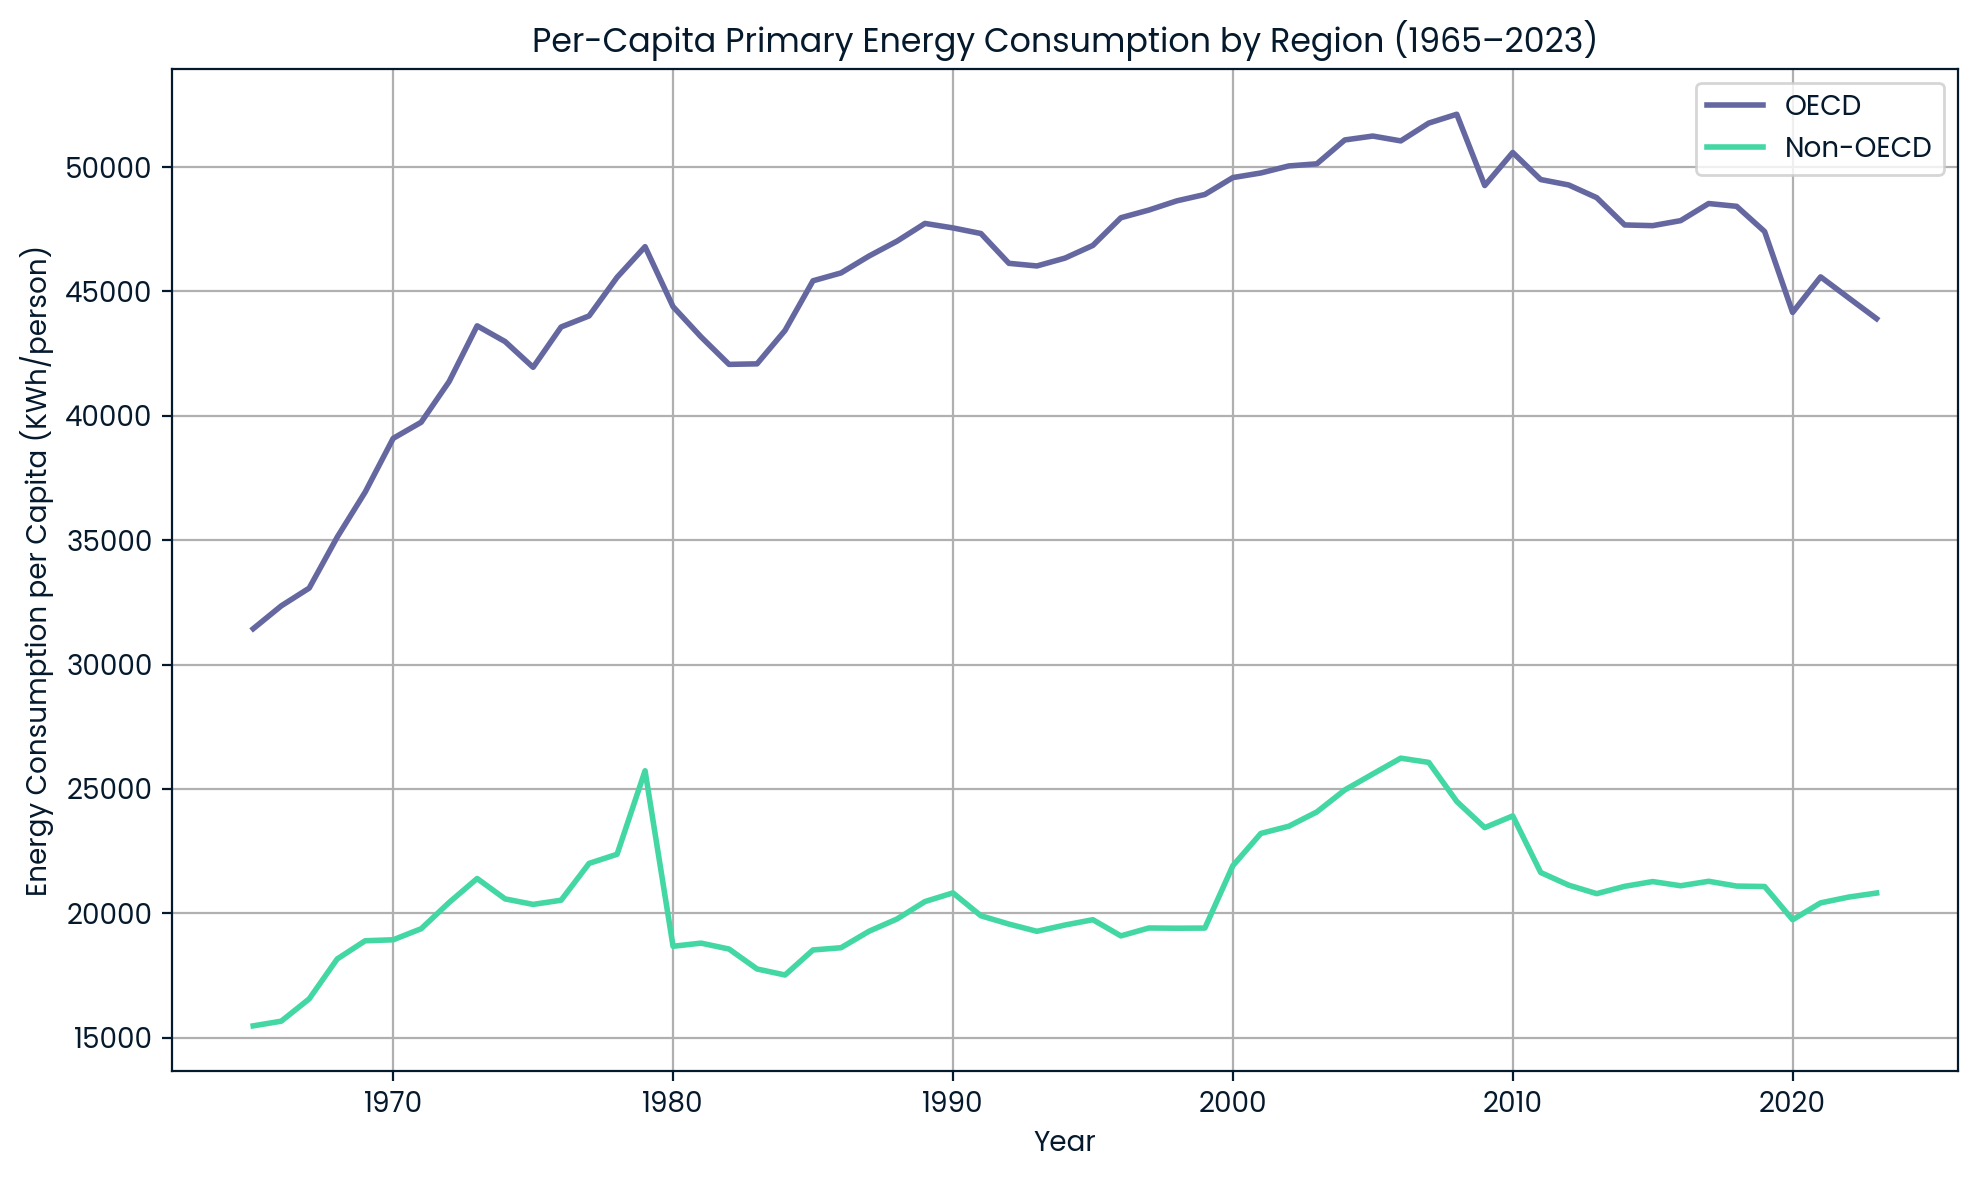

In [15]:
#plotting the trend for per capita energy consumption across both regions 

plt.figure(figsize=(10, 6))

plt.plot(
    per_capita_pivot.index,
    per_capita_pivot["OECD"],
    label="OECD",
    linewidth=2
)

plt.plot(
    per_capita_pivot.index,
    per_capita_pivot["Non-OECD"],
    label="Non-OECD",
    linewidth=2
)


plt.title("Per-Capita Primary Energy Consumption by Region (1965–2023)")
plt.xlabel("Year")
plt.ylabel("Energy Consumption per Capita (KWh/person)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("q1b_oecd_non_oecd_per_capita_energy.png", dpi=300, bbox_inches="tight")
plt.show()


**Data coverage note:** 2024 values are excluded because Non-OECD reporting drops sharply in the final year, which would weaken comparability. The Q1B comparison therefore uses 1965–2023 as the stable coverage window.

### Interpretation

OECD per-capita energy consumption remains consistently higher across the full period, indicating greater average energy intensity per person. This reflects the fact that people in OECD economies tend to live within more energy-intensive systems overall, including transport, buildings, industry, heating, and broader infrastructure and commercial activity. Non-OECD per-capita consumption gradually rises over time, reflecting industrialization and expanding access to modern energy services, but it remains well below OECD levels throughout.

This helps explain the result from Q1A: Non-OECD regions now account for a larger share of total energy-demand growth not because they use more energy per person, but because total demand is being driven by scale — especially larger populations and expanding economies. Taken together, Q1A and Q1B show that future global energy-demand growth is increasingly concentrated outside the OECD even as the per-capita energy gap persists.

# QUESTION 2. How have fossil-fuel and low-carbon energy consumption evolved over time in OECD vs Non-OECD regions?

### WHY DOES THIS QUESTION MATTER?
This comparison shows whether OECD and Non-OECD energy systems are changing mainly through fossil-fuel expansion, low-carbon growth, or both. Looking at consumption levels rather than shares helps reveal the scale of energy demand behind the transition.


### DATA PREPARATION

Fossil-fuel and low-carbon consumption series contain substantial missingness in earlier decades, so the analysis is restricted to 1965 onward to preserve a more consistent regional comparison window.

In [16]:
# selecting the columns required for Q2
q2_columns = [
    "country",
    "year",
    "region_type",
    "fossil_fuel_consumption",
    "low_carbon_consumption"
]

energy_mix_df = df[q2_columns].copy()

# restricting years to 1965 onward for more stable coverage
energy_mix_df = energy_mix_df[energy_mix_df["year"] >= 1965].copy()

# aggregating regional totals by year
energy_mix_grouped = (
    energy_mix_df
    .groupby(["year", "region_type"])[["fossil_fuel_consumption", "low_carbon_consumption"]]
    .sum()
    .reset_index()
)

# pivotting for plotting
energy_mix_pivot = energy_mix_grouped.pivot(
    index="year",
    columns="region_type",
    values=["fossil_fuel_consumption", "low_carbon_consumption"]
)

### FOSSIL-FUEL CONSUMPTION

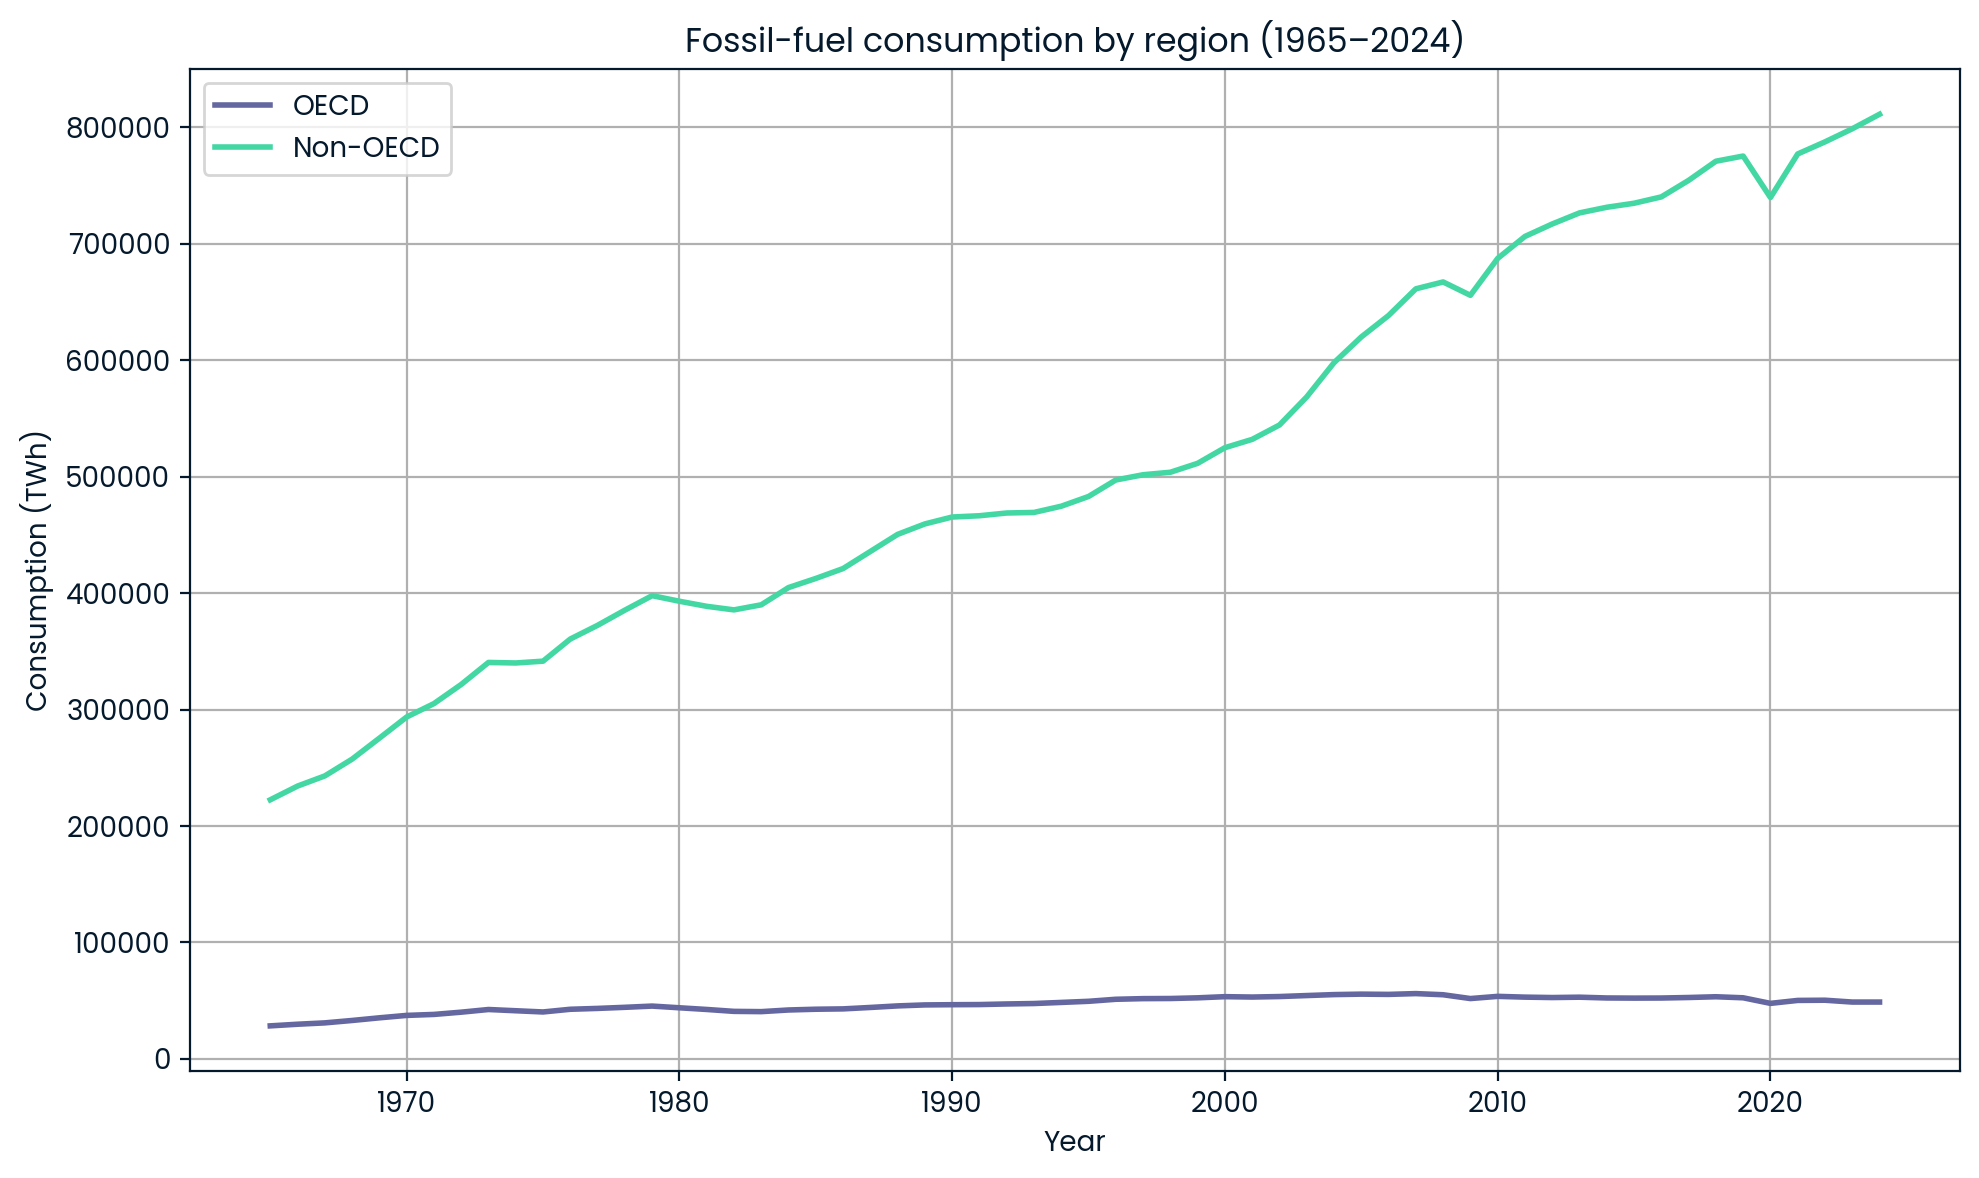

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    energy_mix_pivot.index,
    energy_mix_pivot["fossil_fuel_consumption"]["OECD"],
    label="OECD",
    linewidth=2
)

plt.plot(
    energy_mix_pivot.index,
    energy_mix_pivot["fossil_fuel_consumption"]["Non-OECD"],
    label="Non-OECD",
    linewidth=2
)

plt.title("Fossil-fuel consumption by region (1965–2024)")
plt.xlabel("Year")
plt.ylabel("Consumption (TWh)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation

Fossil-fuel consumption rises in both regions, but the increase is far larger in Non-OECD economies, where total energy demand expands rapidly over time. In OECD economies, fossil-fuel consumption grows more modestly and becomes relatively stable in the later period.

### LOW-CARBON CONSUMPTION

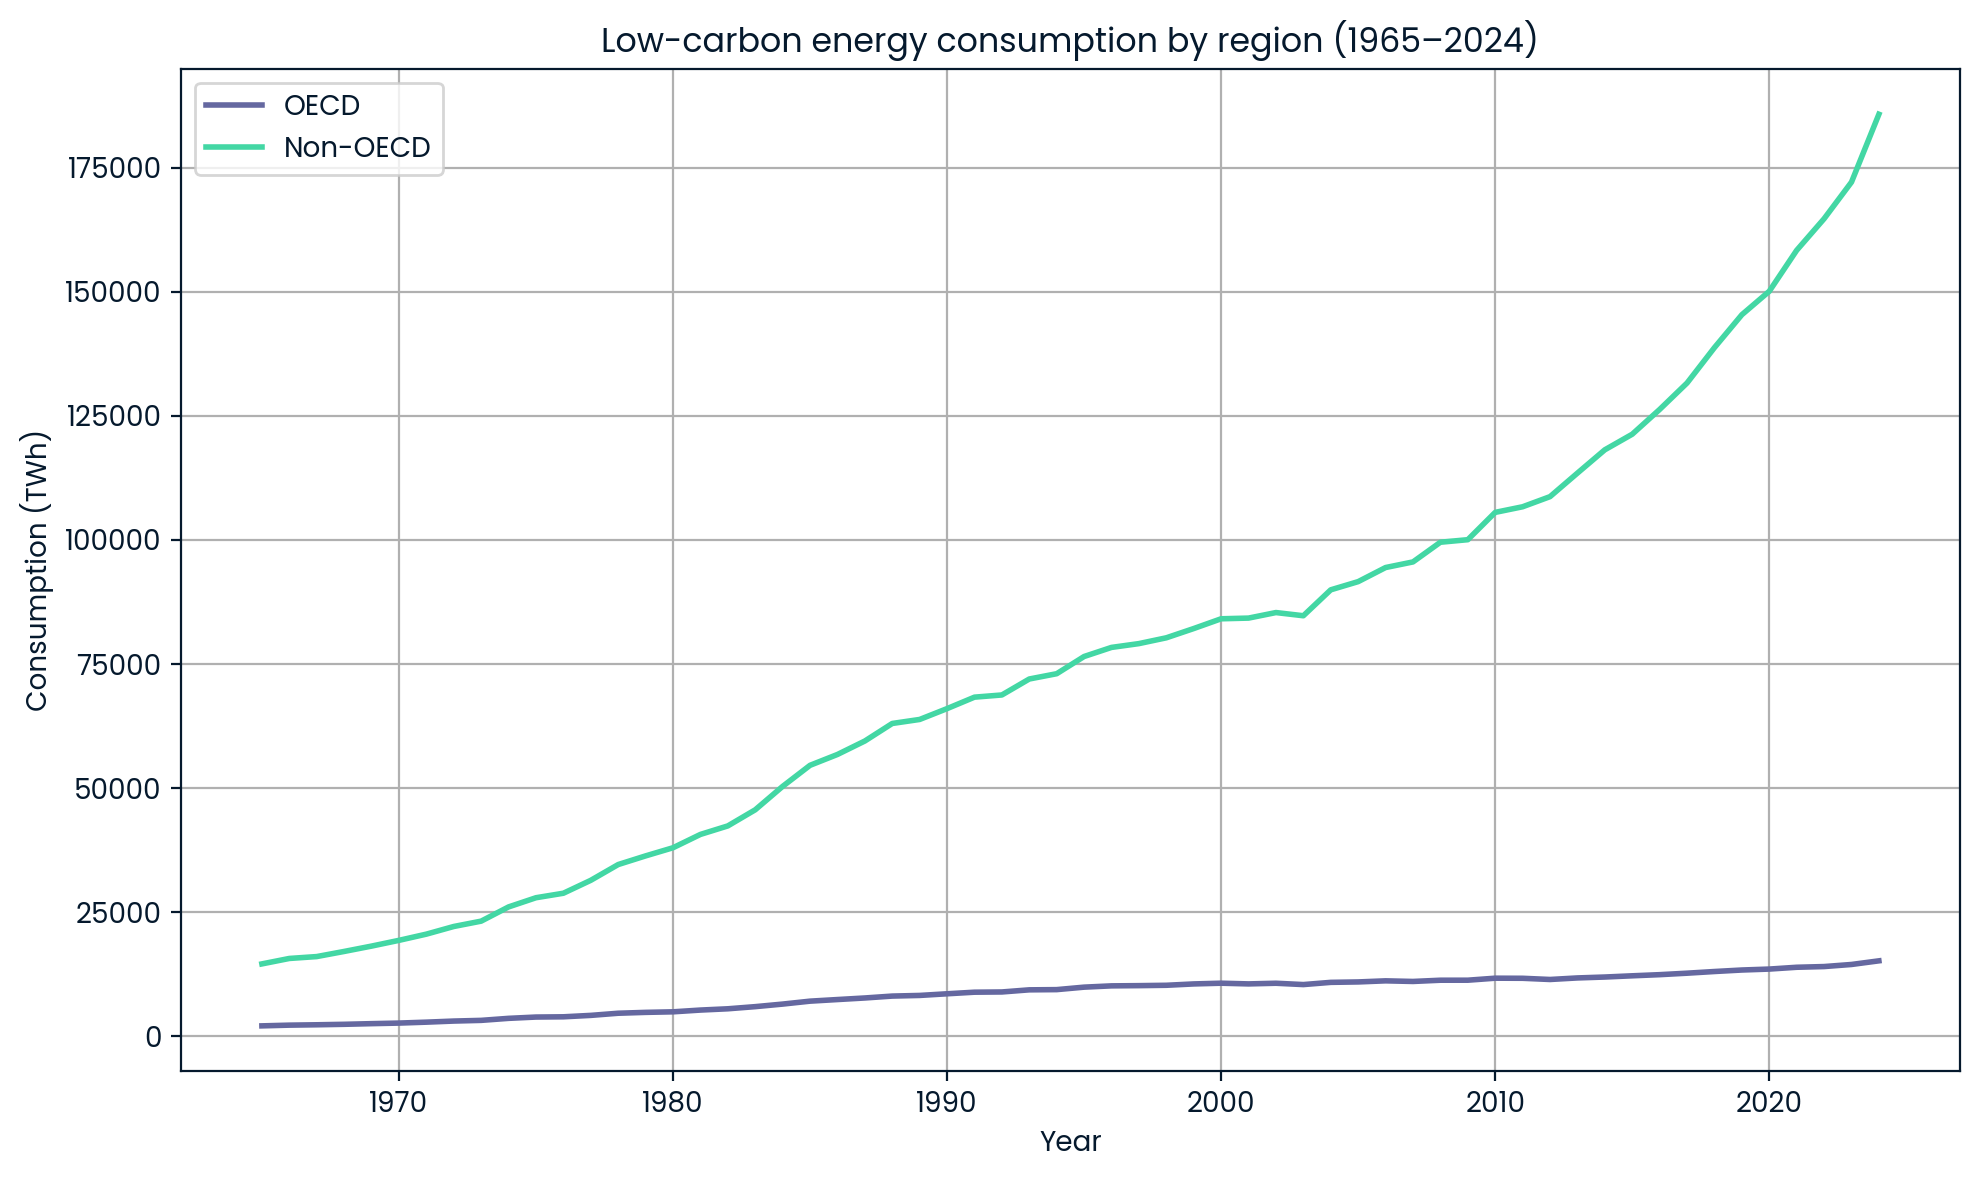

In [18]:
plt.figure(figsize=(10, 6))

plt.plot(
    energy_mix_pivot.index,
    energy_mix_pivot["low_carbon_consumption"]["OECD"],
    label="OECD",
    linewidth=2
)

plt.plot(
    energy_mix_pivot.index,
    energy_mix_pivot["low_carbon_consumption"]["Non-OECD"],
    label="Non-OECD",
    linewidth=2
)

plt.title("Low-carbon energy consumption by region (1965–2024)")
plt.xlabel("Year")
plt.ylabel("Consumption (TWh)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation

Low-carbon consumption also increases in both regions, with especially strong absolute growth in Non-OECD economies in recent decades. This shows that energy expansion outside the OECD is not purely fossil-based: low-carbon energy is also scaling rapidly. However, because fossil-fuel consumption also continues to rise in absolute terms, the results suggest that much of this low-carbon growth is occurring alongside expanding total demand rather than fully displacing fossil fuels.


### Q2 COMPARISON SUMMARY

In [19]:
q2_checkpoints = [1965, 1990, 2010, 2024]

q2_summary = (
    energy_mix_grouped[energy_mix_grouped["year"].isin(q2_checkpoints)]
    .pivot(index="year", columns="region_type", values=["fossil_fuel_consumption", "low_carbon_consumption"])
)

q2_summary.columns = [
    "Fossil — Non-OECD",
    "Fossil — OECD",
    "Low-carbon — Non-OECD",
    "Low-carbon — OECD"
]

q2_summary = q2_summary.reset_index()
q2_summary = q2_summary.round(1)

q2_summary

,year,Fossil — Non-OECD,Fossil — OECD,Low-carbon — Non-OECD,Low-carbon — OECD
0,1965,222527.1,28367.0,14596.5,2115.6
1,1990,465393.2,46544.1,66020.2,8577.1
2,2010,687500.7,53706.6,105547.1,11718.3
3,2024,811322.5,48811.0,185744.2,15213.5


### Q2 TAKEAWAY

Taken together, the Q2 results indicate that Non-OECD regions are driving most of the growth in both fossil-fuel and low-carbon energy consumption in absolute terms. The key transition challenge is therefore not simply whether low-carbon energy is growing, but whether it is growing fast enough to displace fossil demand rather than expand alongside it.

The checkpoint comparison above confirms that Non-OECD regions account for most of the absolute increase in both fossil-fuel and low-carbon consumption.

# QUESTION 3: How has the carbon intensity of Electricity evolved across OECD and Non-OECD regions over time?

### WHY DOES THIS QUESTION MATTER?

Carbon intensity of electricity shows how emissions-heavy power generation is on average. A lower value means electricity is being produced with less CO₂ per unit of output, which usually reflects cleaner generation mixes, efficiency gains, or reduced reliance on coal and other high-emission fuels.

### DATA PREPARATION AND AGGREGATION

**Method note:** Q3 uses the average of country-level electricity carbon-intensity values within each region for each year.

In [20]:
# selecting the columns required for Q3
q3_columns = ["country", "year", "region_type", "carbon_intensity_elec"]
carbon_df = df[q3_columns].copy()

# restricting to 2000 onward for a more stable regional coverage
carbon_df = carbon_df[carbon_df["year"] >= 2000].copy()

# aggregating regional average carbon intensity by year
carbon_grouped = (
    carbon_df
    .groupby(["year", "region_type"])["carbon_intensity_elec"]
    .mean()
    .reset_index()
)

# pivoting for plotting
carbon_pivot = carbon_grouped.pivot(
    index="year",
    columns="region_type",
    values="carbon_intensity_elec"
)

### CARBON INTENSITY OF ELECTRICITY

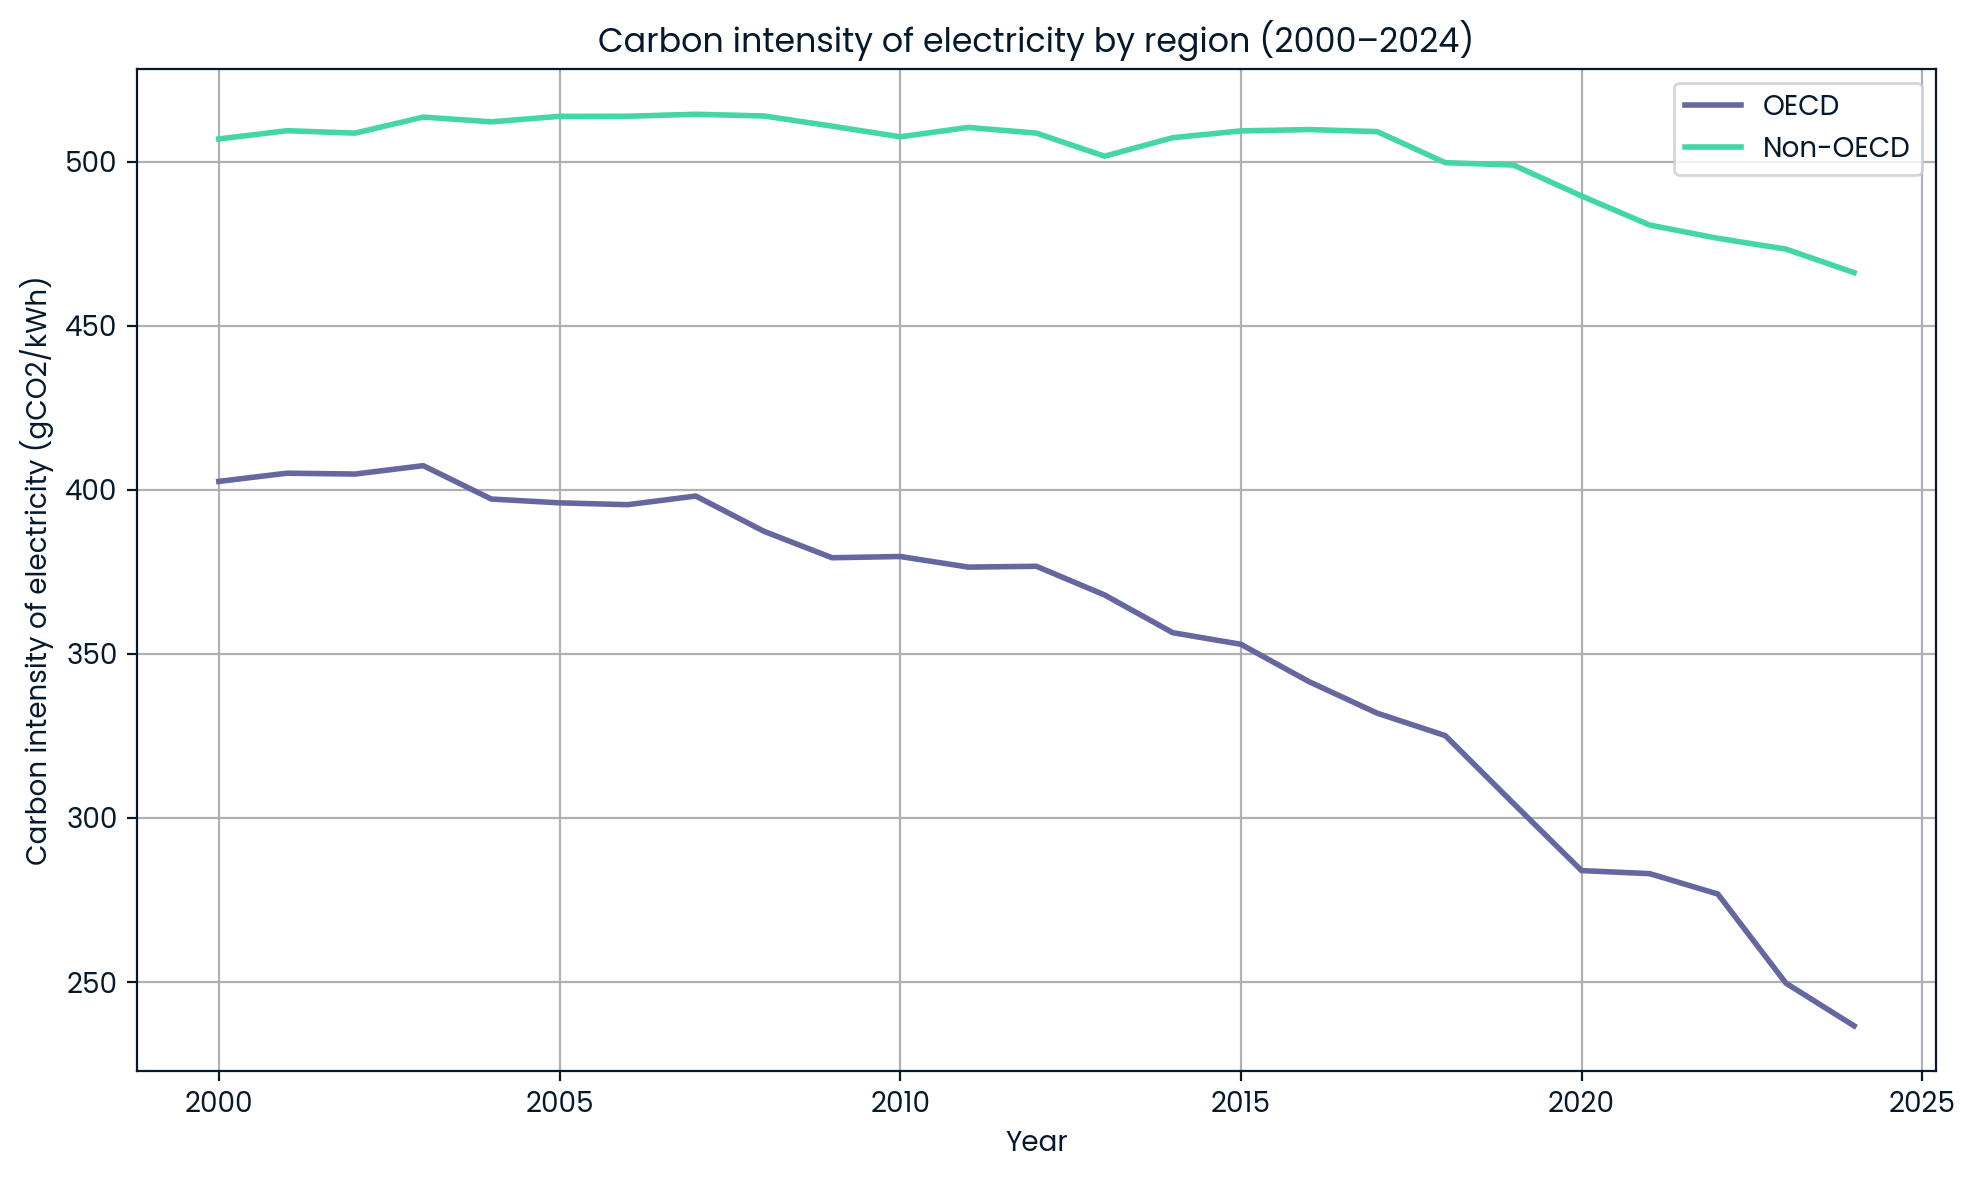

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    carbon_pivot.index,
    carbon_pivot["OECD"],
    label="OECD",
    linewidth=2
)

plt.plot(
    carbon_pivot.index,
    carbon_pivot["Non-OECD"],
    label="Non-OECD",
    linewidth=2
)

plt.title("Carbon intensity of electricity by region (2000–2024)")
plt.xlabel("Year")
plt.ylabel("Carbon intensity of electricity (gCO2/kWh)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation

From 2000 to 2024, average electricity carbon intensity declines in both OECD and Non-OECD regions, which indicates that power generation is becoming cleaner on average in both groups. The decline is much steeper in OECD economies, where carbon intensity falls from just above 400 gCO2/kWh to roughly the mid-200s by the end of the period.

Non-OECD carbon intensity also trends downward, but much more gradually, staying near or above 500 gCO2/kWh for much of the period before declining more noticeably in the later years. This suggests that, although cleaner generation is expanding outside the OECD, fossil-heavy power systems still remain more persistent on average.

The widening gap between the two lines after roughly 2010 points to faster power-sector decarbonisation in OECD regions than in Non-OECD regions over this window.

### Q3 COMPARISON SUMMARY

In [22]:
q3_checkpoints = [2000, 2010, 2024]

q3_summary = (
    carbon_grouped[carbon_grouped["year"].isin(q3_checkpoints)]
    .pivot(index="year", columns="region_type", values="carbon_intensity_elec")
    .reset_index()
    .round(1)
)

q3_summary.columns = ["year", "Non-OECD", "OECD"]
q3_summary = q3_summary.reset_index(drop=True)
q3_summary

,year,Non-OECD,OECD
0,2000,506.9,402.5
1,2010,507.5,379.7
2,2024,466.2,236.6


### Q3 TAKEAWAY

Q3 shows that electricity is getting cleaner in both OECD and Non-OECD regions, but the pace of decarbonisation is much faster in OECD power systems over the 2000–2024 period. Non-OECD regions improve as well, though their average electricity generation remains more carbon-intensive throughout the comparison window.

# QUESTION 4: How has the electricity generation mix shifted across OECD and Non-OECD regions over time?

### WHY DOES THIS QUESTION MATTER?

Electricity-sector decarbonisation depends not just on how much electricity is produced, but on which sources generate it. Looking at source shares helps show whether coal is losing ground, whether gas is expanding or stabilising, and how strongly low-carbon sources such as hydro, nuclear, wind, and solar are contributing over time.

### DATA PREPARATION AND COVERAGE DECISION

Source-level electricity-generation data is much less complete in earlier decades, especially once generation is split into coal, gas, oil, nuclear, hydro, wind, and solar. Because the number of country observations changes over time, raw missing-value counts are not directly comparable across years. Missing percentages are therefore used to assess data coverage more fairly, since they show how incomplete each year is relative to the amount of data available.


In [23]:
#defining datasets and technology columns required for this analysis 
q4_cols = [
    "country", "year", "region_type",
    "coal_electricity", "gas_electricity", "oil_electricity",
    "nuclear_electricity", "hydro_electricity",
    "wind_electricity", "solar_electricity"
]

elec_mix_df = df[q4_cols].copy()

elec_mix_cols = [
    "coal_electricity", "gas_electricity", "oil_electricity",
    "nuclear_electricity", "hydro_electricity",
    "wind_electricity", "solar_electricity"
]

In [24]:
#checking for missingness by year in percentages
missing_pct_by_year = (
    elec_mix_df
    .groupby("year")[elec_mix_cols]
    .apply(lambda x: x.isna().mean().mean() * 100)
    .reset_index(name="avg_missing_pct")
)

missing_pct_compare = missing_pct_by_year[
    missing_pct_by_year["year"].isin([1985, 1990, 2000, 2005, 2010, 2020])
].copy()

missing_pct_compare["avg_missing_pct"] = missing_pct_compare["avg_missing_pct"].round(2)
missing_pct_compare

missing_pct_compare

,year,avg_missing_pct
85,1985,68.99
90,1990,64.95
100,2000,17.97
105,2005,17.67
110,2010,17.59
120,2020,12.97


Missingness is extremely high across the earlier decades of the dataset and remains elevated into the early 1990s, but falls materially by 2000 and stays much lower thereafter. Because source-level coverage is more stable in the later period, Q4 focuses on a post-2000 comparison window.

**Note:** Earlier exploratory checks showed that the number of country observations changes over time, so missing percentages were preferred over raw missing counts when selecting the comparison window.

### REGIONAL AGGREGATION AND SHARE CALCULATION

In [25]:
# restricting to later years with more stable source coverage
elec_mix_q4 = elec_mix_df.loc[
    elec_mix_df["year"] >= 2000,
    ["year", "region_type"] + elec_mix_cols
].copy()

# aggregating regional generation by year and region
elec_mix_trend = (
    elec_mix_q4
    .groupby(["year", "region_type"], as_index=False)[elec_mix_cols]
    .sum(min_count=1)
)

After aggregating generation by year and region, each source was divided by the sum of the selected source columns for that region-year to calculate source shares. These were then grouped into fossil and low-carbon categories for easier comparison.

In [26]:
# adding a new column required for converting source-specific generation levels into source shares
elec_mix_trend["selected_source_total"] = (
    elec_mix_trend[elec_mix_cols].sum(axis=1, min_count=1)
)

for c in elec_mix_cols:
    share_name = c.replace("_electricity", "_share")
    elec_mix_trend[share_name] = (
        elec_mix_trend[c] / elec_mix_trend["selected_source_total"]
    )

share_cols = [c.replace("_electricity", "_share") for c in elec_mix_cols]

In [27]:
# combining source shares into broader categories
elec_mix_trend["fossil_share"] = elec_mix_trend[
    ["coal_share", "gas_share", "oil_share"]
].sum(axis=1).round(2)

elec_mix_trend["low_carbon_share"] = elec_mix_trend[
    ["nuclear_share", "hydro_share", "wind_share", "solar_share"]
].sum(axis=1).round(2)

elec_mix_trend[["year", "region_type", "fossil_share", "low_carbon_share"]].head()

,year,region_type,fossil_share,low_carbon_share
0,2000,Non-OECD,0.65,0.35
1,2000,OECD,0.62,0.38
2,2001,Non-OECD,0.65,0.35
3,2001,OECD,0.62,0.38
4,2002,Non-OECD,0.66,0.34


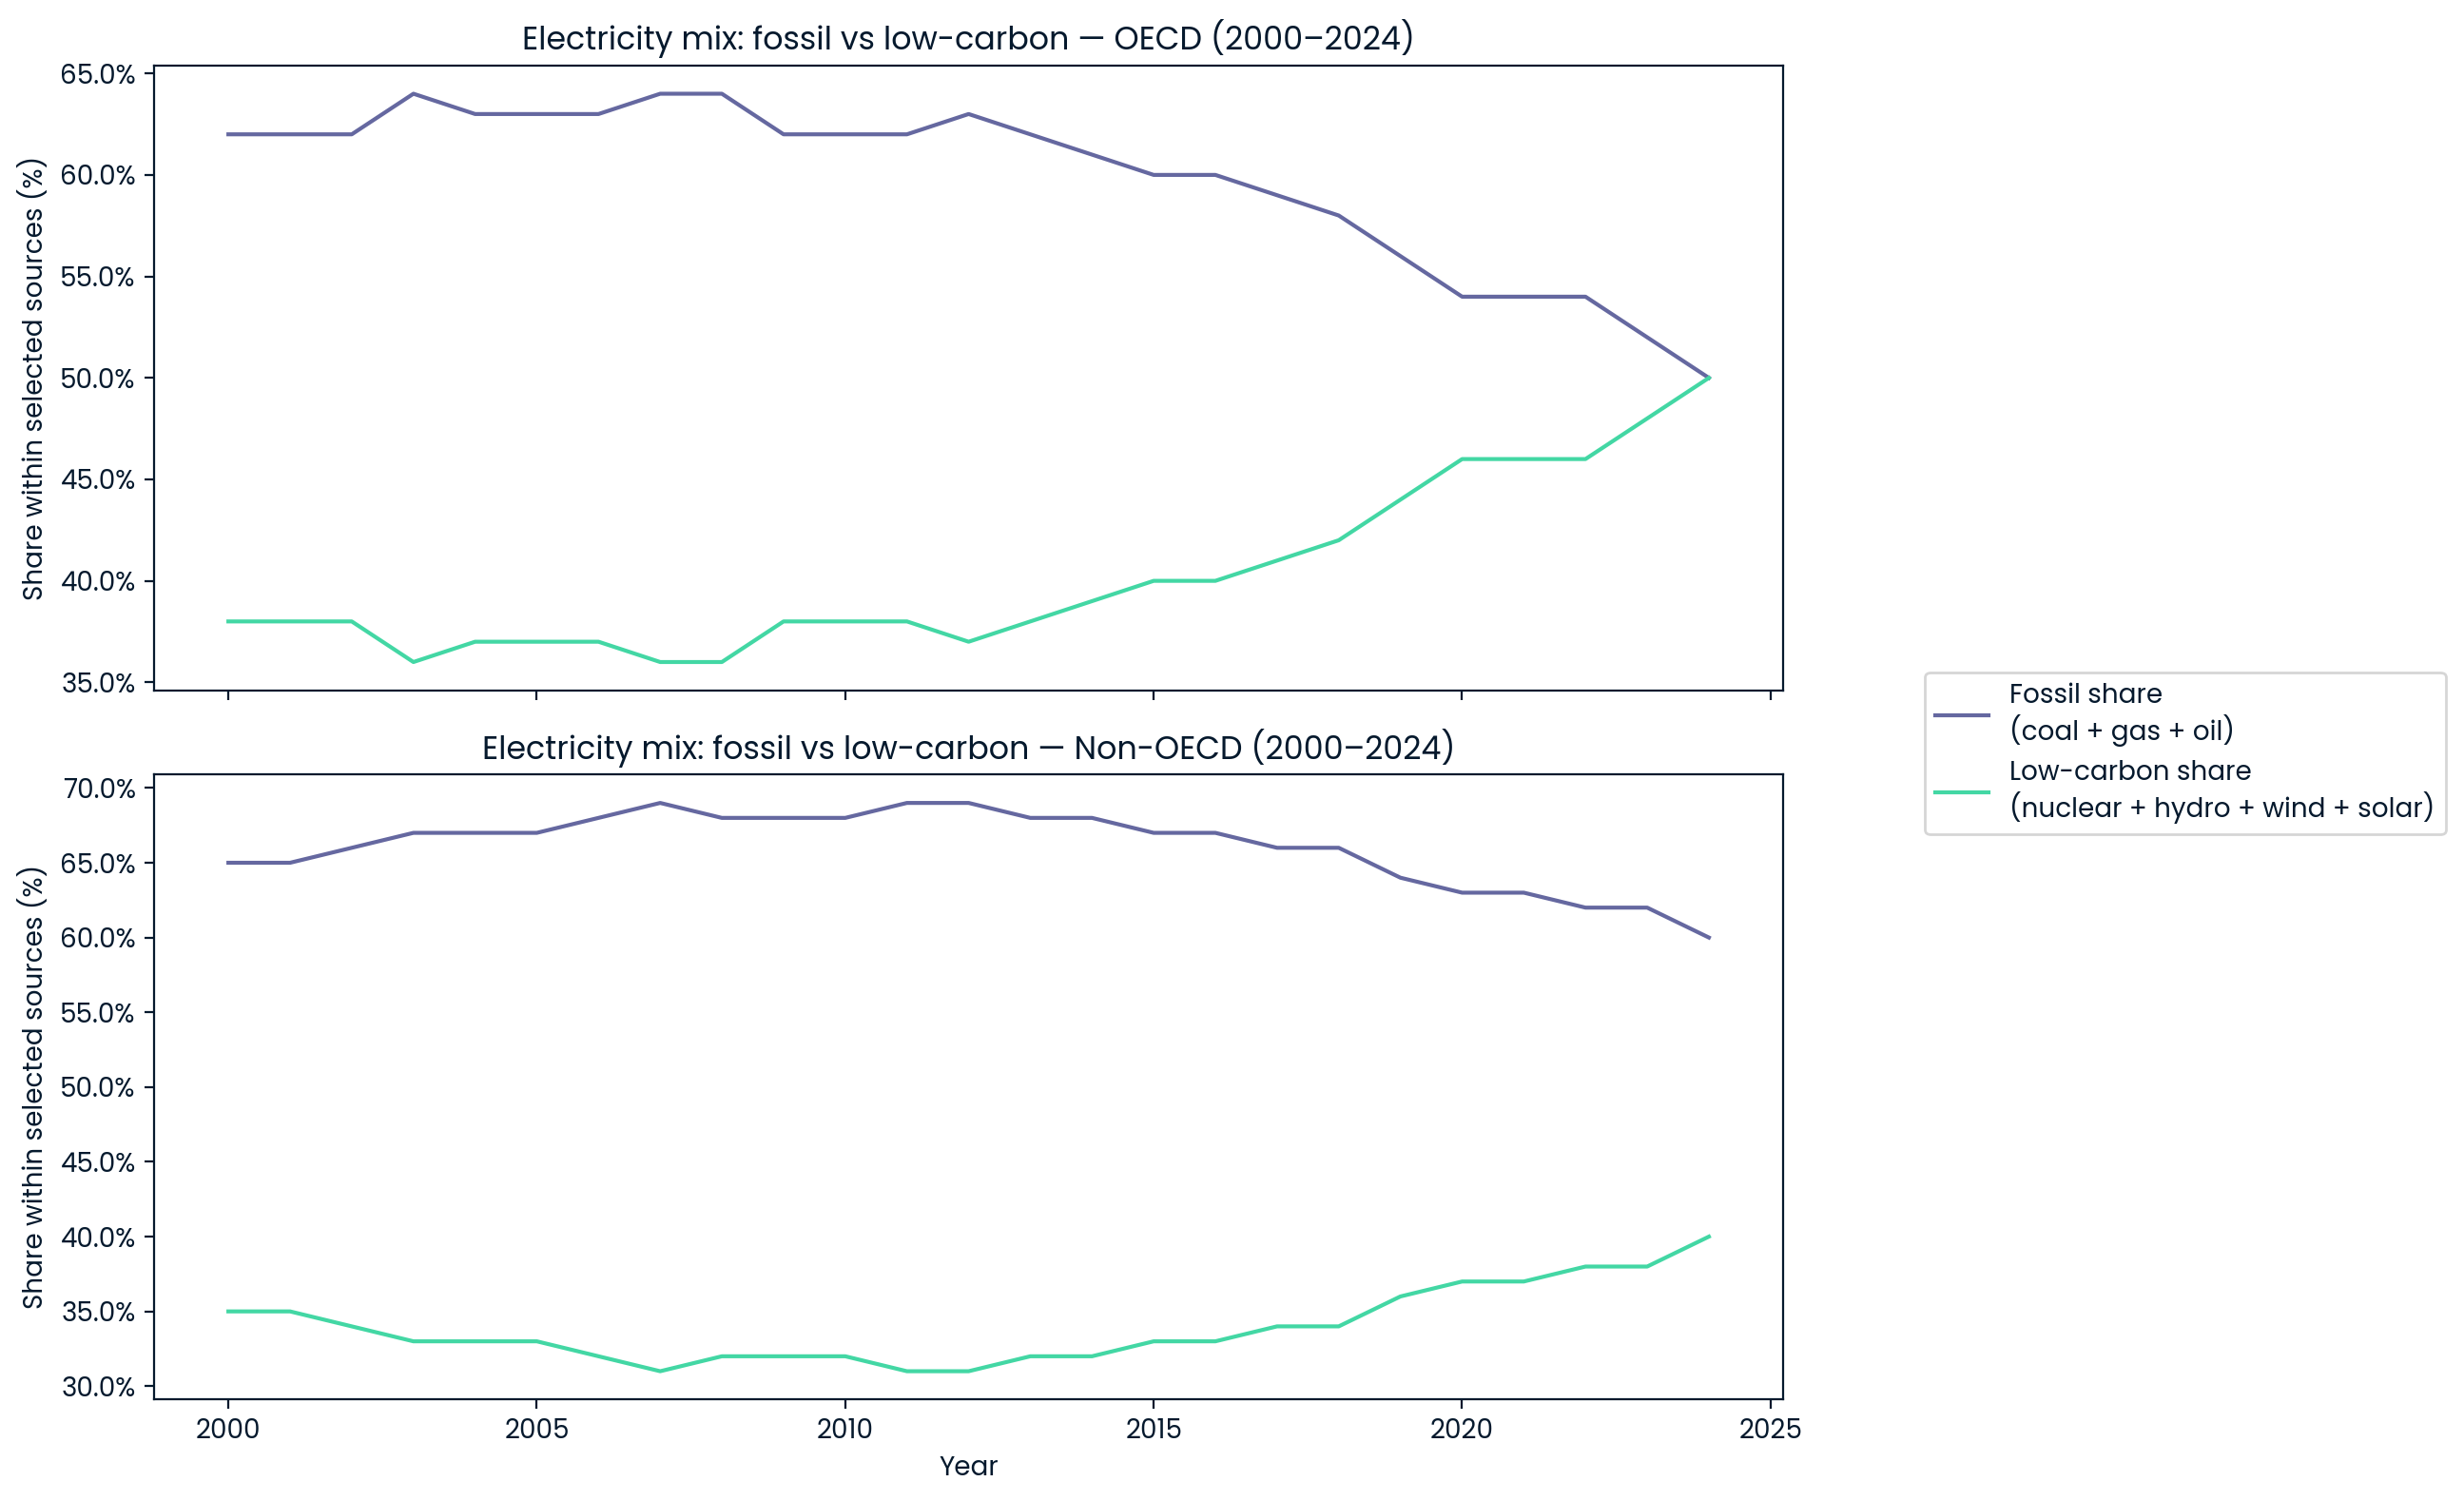

In [28]:
#plotting the fossil vs low carbon shsfor clear visualization

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

regions = ["OECD", "Non-OECD"]

for ax, region in zip(axes, regions):
    d = (
        elec_mix_trend[elec_mix_trend["region_type"] == region]
        .sort_values("year")
    )

    ax.plot(
        d["year"], d["fossil_share"],
        label="Fossil share\n(coal + gas + oil)"
    )
    ax.plot(
        d["year"], d["low_carbon_share"],
        label="Low-carbon share\n(nuclear + hydro + wind + solar)"
    )

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(f"Electricity mix: fossil vs low-carbon — {region} (2000–2024)")
    ax.set_ylabel("Share within selected sources (%)")

axes[-1].set_xlabel("Year")

# Shared legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="center right",
    bbox_to_anchor=(1.18, 0.5),
    fontsize=10
)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.savefig(
    "q4_oecd_non_oecd_fossil_vs_low_carbon_electricity_share.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### SUPPORTING Q4 FIGURE: STACKED-AREA SOURCE MIX

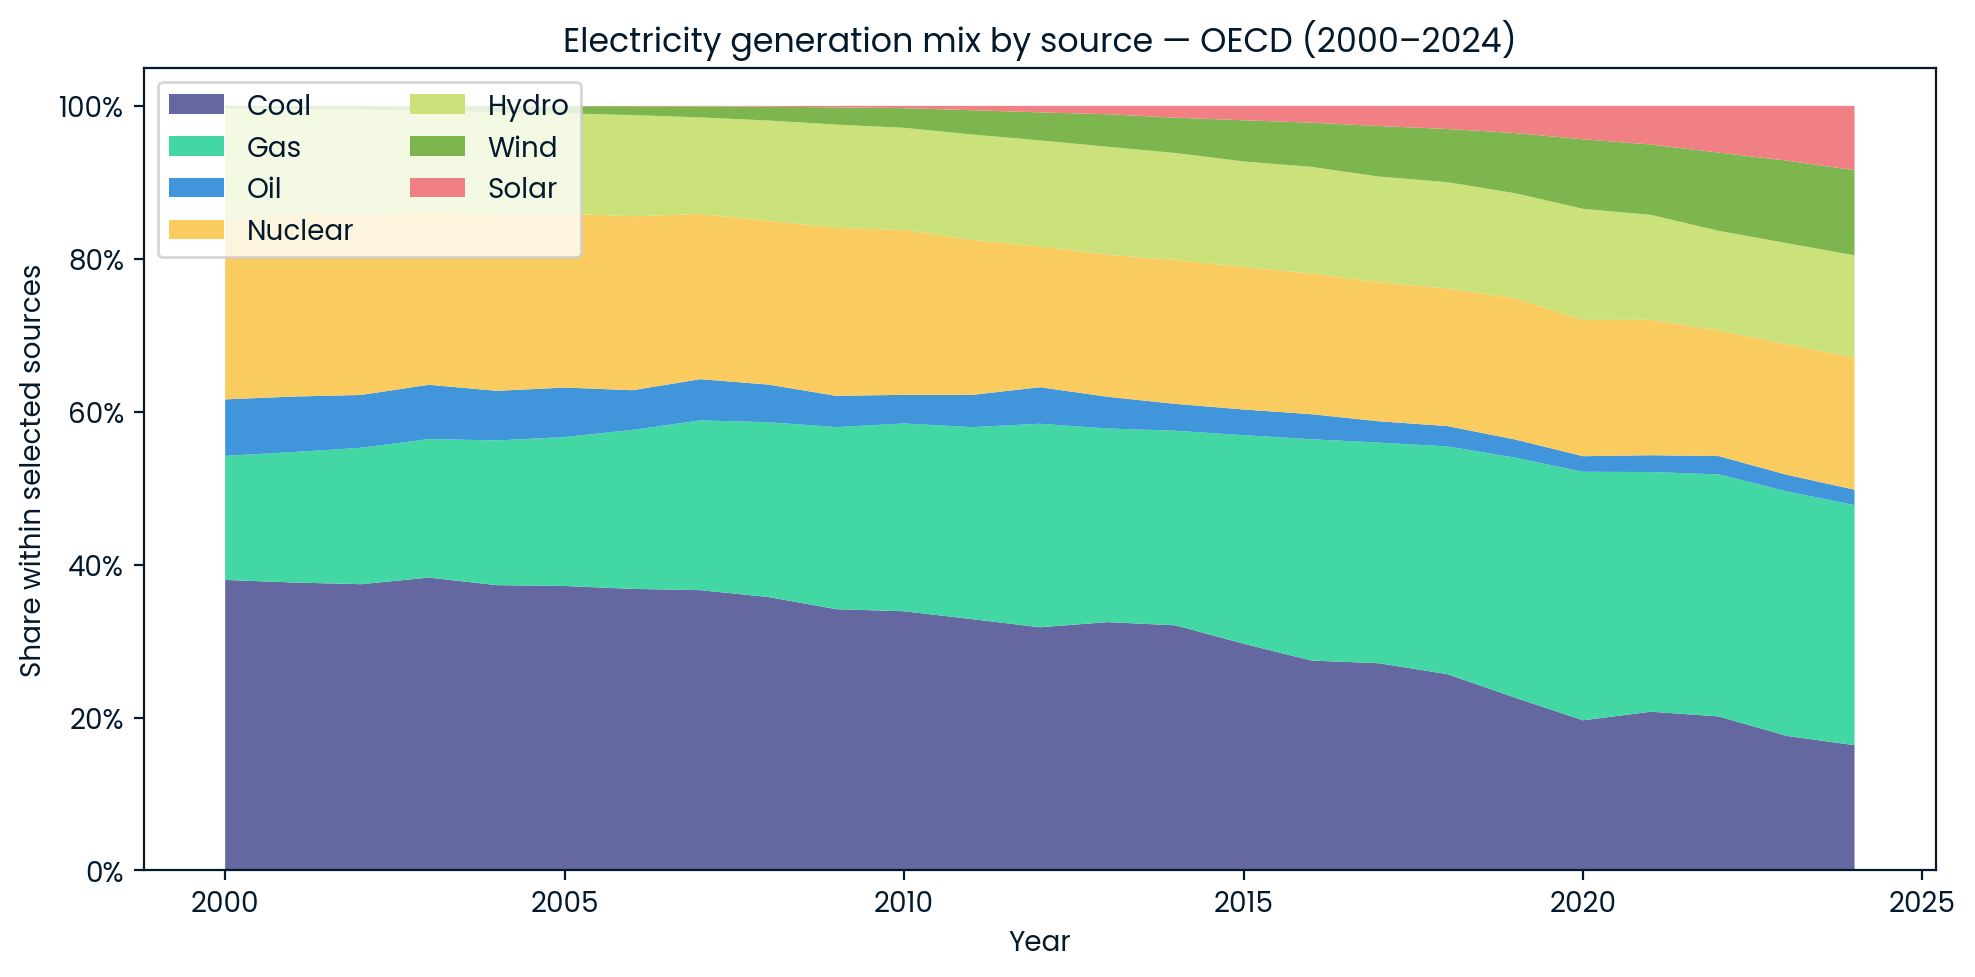

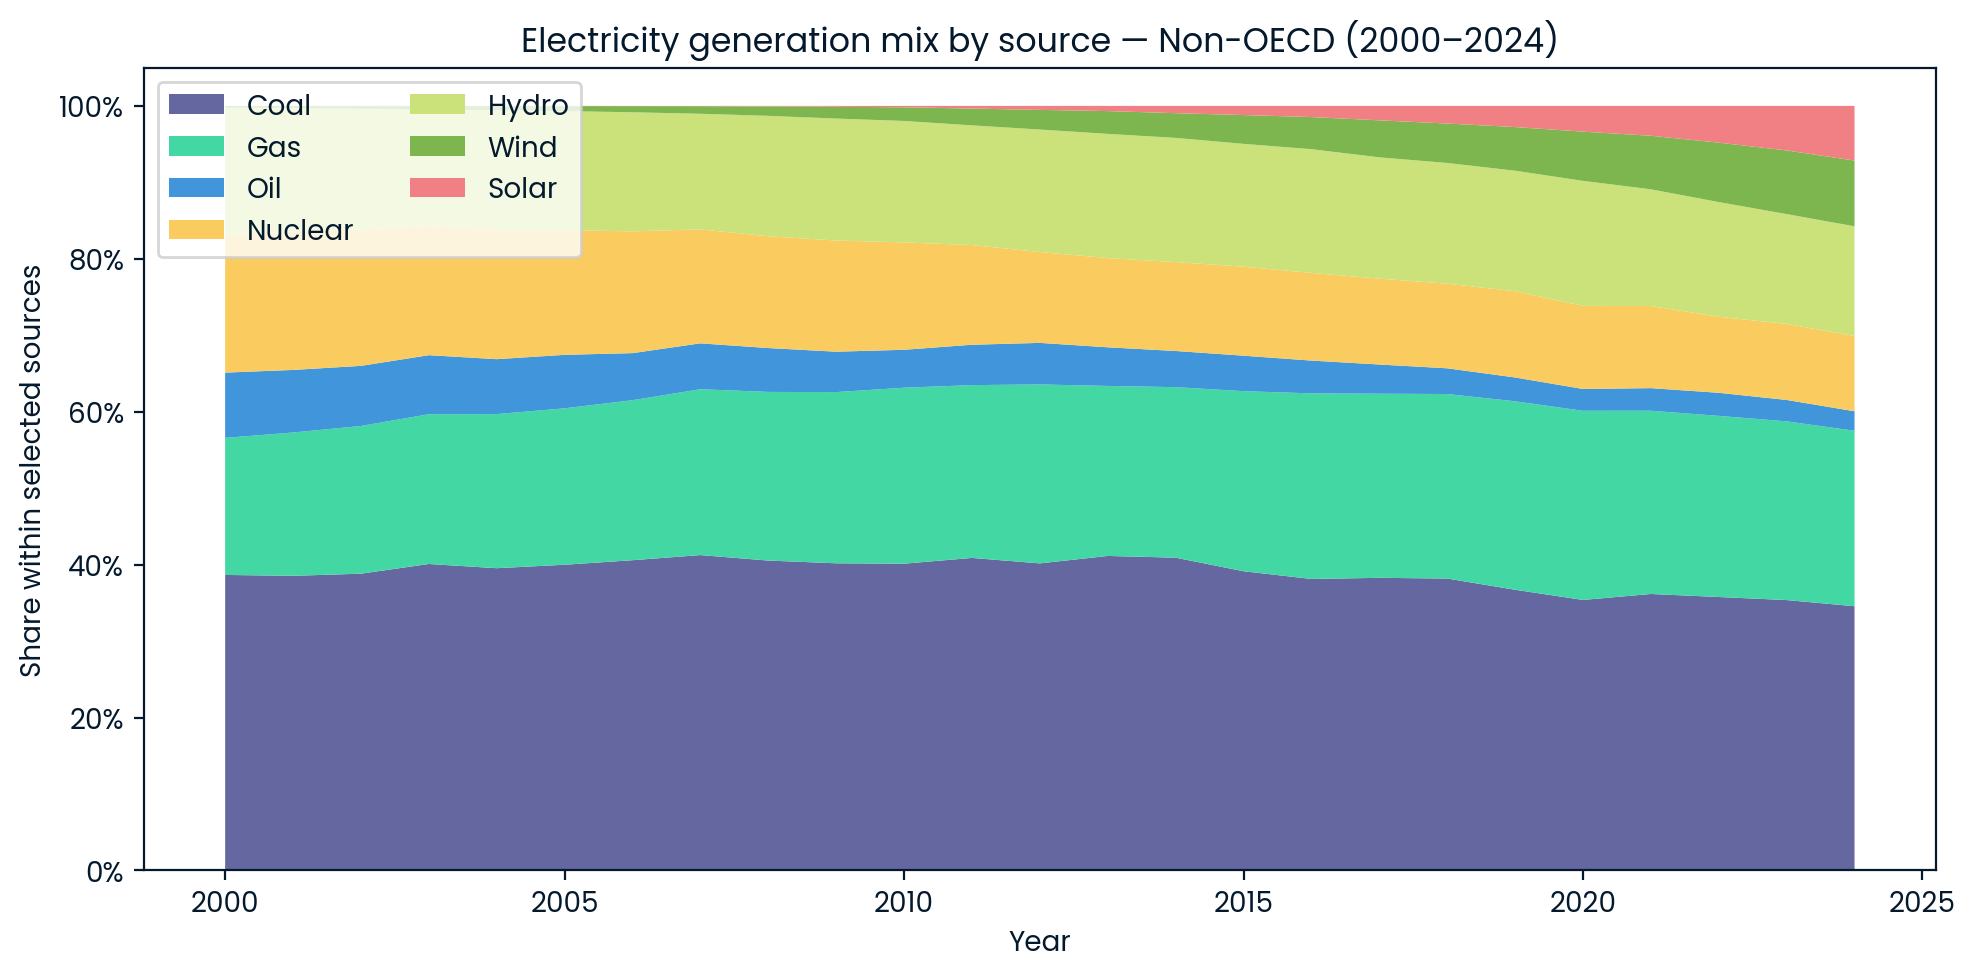

In [29]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

label_map = {
    "coal_share": "Coal",
    "gas_share": "Gas",
    "oil_share": "Oil",
    "nuclear_share": "Nuclear",
    "hydro_share": "Hydro",
    "wind_share": "Wind",
    "solar_share": "Solar",
}

for region in ["OECD", "Non-OECD"]:
    d = (
        elec_mix_trend[elec_mix_trend["region_type"] == region]
        .sort_values("year")
        .set_index("year")[list(label_map.keys())]
        .rename(columns=label_map)
    )

    plt.figure(figsize=(10, 5))
    plt.stackplot(d.index, d.T.values, labels=d.columns)
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.title(f"Electricity generation mix by source — {region} (2000–2024)")
    plt.ylabel("Share within selected sources")
    plt.xlabel("Year")
    plt.legend(loc="upper left", ncol=2)
    plt.tight_layout()
    plt.show()

### Q4 RESULTS NOTE: How the electricity generation mix shifted across OECD vs Non-OECD regions over time (2000–2024)

- To compare electricity-mix changes across regions, I aggregated annual electricity generation by source for OECD and Non-OECD regions, then converted each source into a share of the selected electricity-generation sources. Because earlier decades have much weaker source-level coverage, the final comparison focuses on 2000–2024, where coverage is more stable. The fossil vs low-carbon line chart is used as the main comparative summary, while the stacked-area charts provide supporting detail on how individual technologies drive the broader mix changes.

### Interpretation

1. **OECD**
- The OECD electricity mix becomes steadily less fossil-heavy over time. The stacked-area chart shows coal losing a substantial share, while gas remains important through much of the transition rather than disappearing immediately. On the low-carbon side, hydro and nuclear provide a relatively stable base, but the strongest later shift comes from wind and solar, which expand more visibly from the mid-2010s onward. The fossil vs low-carbon line chart confirms this broader pattern: the fossil share trends downward, the low-carbon share rises, and the two converge at roughly 50/50 by 2024.
2. **Non-OECD**
- The Non-OECD mix also shifts toward lower-carbon generation, but more gradually. Coal remains the dominant source throughout the period, and although gas grows, it does not replace coal in the way seen in the OECD transition story. Low-carbon electricity does gain share, with hydro providing a steady contribution and wind/solar becoming more visible in the later years, but the overall mix remains more fossil-led by 2024. This is reflected clearly in the line chart, where fossil generation stays well above low-carbon generation across the full period.
3. **Regional contrast**
- Taken together, the charts suggest faster electricity-sector decarbonisation in the OECD than in the Non-OECD. In the OECD, the gap between fossil and low-carbon shares narrows sharply over time, indicating a stronger rebalancing of the power mix. In the Non-OECD, low-carbon sources do expand, but fossil generation remains more deeply embedded in the system. This means both regions show transition progress, but the OECD moves further and faster toward a lower-carbon electricity mix.

### KEY TAKEAWAY
From 2000 to 2024, both OECD and Non-OECD regions shift toward lower-carbon electricity generation, but the change is much more pronounced in the OECD. OECD systems reach near fossil/low-carbon parity by the end of the period, while Non-OECD systems remain more strongly anchored in fossil generation despite visible low-carbon growth.

### SCOPE NOTE
Shares are calculated within the selected source categories shown in the charts: coal, gas, oil, nuclear, hydro, wind, and solar. The results therefore describe how the mix changes across those tracked technologies, rather than the full electricity system if additional sources exist outside the selected set.

# QUESTION 5: How has Canada’s renewables share of primary energy evolved compared to the world? 

### WHY DOES THIS QUESTION MATTER?

This section focuses on Canada’s renewables share of primary energy relative to the world average to assess whether Canada’s long-run transition toward renewable energy has been stronger or weaker than the global pattern. Supporting comparisons for coal, oil, gas, and nuclear provide additional context by showing how Canada’s wider primary energy structure differs from the world at key checkpoints and across the longer trend.

In [44]:
# Supporting checkpoint comparison for Canada vs World
years = [1985, 2000, 2024]

q5_cols = [
    "coal_share_energy",
    "oil_share_energy",
    "gas_share_energy",
    "nuclear_share_energy",
    "renewables_share_energy",
]

can_world_checkpoints = (
    df.loc[
        df["country"].isin(["Canada", "World"]) & df["year"].isin(years),
        ["country", "year"] + q5_cols
    ]
    .copy()
)

can_world_checkpoints["fossil_total"] = (
    can_world_checkpoints["coal_share_energy"] +
    can_world_checkpoints["oil_share_energy"] +
    can_world_checkpoints["gas_share_energy"]
)

can_world_checkpoints["low_carbon_total"] = (
    can_world_checkpoints["nuclear_share_energy"] +
    can_world_checkpoints["renewables_share_energy"]
)

small_table = (
    can_world_checkpoints
    .rename(columns={
        "coal_share_energy": "Coal (%)",
        "oil_share_energy": "Oil (%)",
        "gas_share_energy": "Gas (%)",
        "nuclear_share_energy": "Nuclear (%)",
        "renewables_share_energy": "Renewables (%)",
        "fossil_total": "Fossil total (%)",
        "low_carbon_total": "Low-carbon total (%)",
    })
    .sort_values(["country", "year"])
)

num_cols = [c for c in small_table.columns if c not in ["country", "year"]]
small_table[num_cols] = small_table[num_cols].round(2)

small_table = small_table.reset_index(drop=True)
small_table

,country,year,Coal (%),Oil (%),Gas (%),Nuclear (%),Renewables (%),Fossil total (%),Low-carbon total (%)
0,Canada,1985,11.14,32.26,20.28,6.01,30.32,63.67,36.33
1,Canada,2000,9.93,31.00,24.93,5.61,28.54,65.85,34.15
2,Canada,2024,2.12,31.64,33.63,5.45,27.16,67.39,32.61
3,World,1985,28.60,40.15,19.39,4.93,6.93,88.14,11.86
4,World,2000,25.01,39.18,21.86,6.53,7.43,86.04,13.96
5,World,2024,26.16,31.55,23.55,3.92,14.82,81.26,18.74


The checkpoint table provides structural context by comparing Canada and the world at three benchmark years across major primary energy sources, while the main figure below focuses specifically on the long-run renewables share trend.

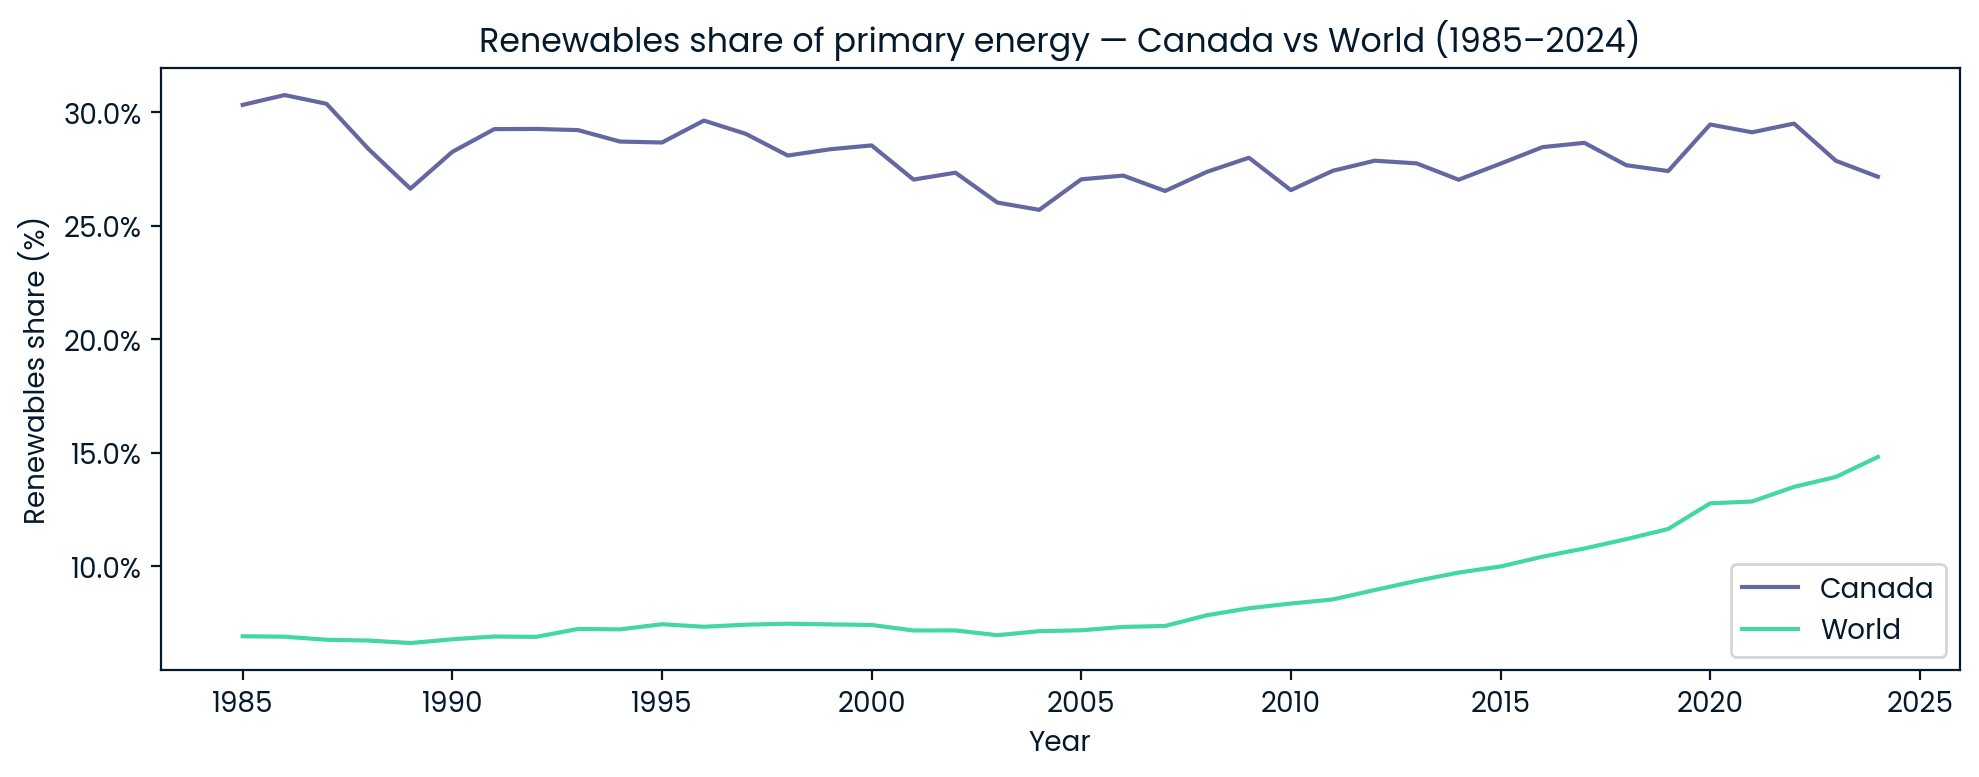

In [31]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plot_df = df[
    df["country"].isin(["Canada", "World"]) &
    df["year"].between(1985, 2024)
][["country", "year", "renewables_share_energy"]].copy()

plt.figure(figsize=(10, 4))

for country in ["Canada", "World"]:
    d = plot_df[plot_df["country"] == country].sort_values("year")
    plt.plot(d["year"], d["renewables_share_energy"], label=country)

plt.title("Renewables share of primary energy — Canada vs World (1985–2024)")
plt.xlabel("Year")
plt.ylabel("Renewables share (%)")
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=100))
plt.legend()
plt.tight_layout()
plt.savefig("q5_canada_vs_world_renewables_share_primary_energy.png", dpi=300, bbox_inches="tight")
plt.show()

### Q5 RESULTS NOTE: Canada vs World renewables share of primary energy (1985–2024)

To compare Canada’s long-run energy transition with the world average, I first used checkpoint years (1985, 2000, and 2024) to show how Canada’s broader primary energy structure differs from the global pattern across coal, oil, gas, nuclear, and renewables. The main figure then focuses specifically on renewables’ share of primary energy, which is the clearest summary metric for comparing how strongly renewable energy contributes to each system over time.

### Interpretation
Canada’s renewables share of primary energy remains consistently far above the world average across the full period. Rather than showing a sudden upward transition, Canada maintains a persistently high renewables share, suggesting a long-standing structural advantage in low-carbon energy, likely driven heavily by hydropower. By contrast, the world average starts from a much lower baseline and rises gradually, especially after 2010, indicating steady but slower renewable penetration at the global level.

The checkpoint table helps place this difference in broader context. Canada consistently has a much lower coal share and a much higher renewables share than the world, while its gas share rises over time. Taken together, this suggests that Canada’s energy transition is characterized less by a late renewables surge and more by a cleaner starting structure combined with continued coal decline and rising gas use. The world also moves toward renewables, but from a far more fossil-heavy baseline.

### KEY TAKEAWAY

Canada’s renewables share of primary energy remains structurally higher than the world average throughout 1985–2024. The global average is catching up gradually, but Canada remains well ahead, reflecting a cleaner starting position rather than just a faster recent transition.

# QUESTION 6: How does Canada compare to similar Economies? (Peer Countries)

### WHY DOES THIS QUESTION MATTER?

Canada is often viewed as having a relatively cleaner energy profile because of its large hydropower base and some nuclear generation. However, comparing Canada with similar advanced economies helps show whether Canada is actually transitioning faster, or whether it simply started from a more favorable low-carbon baseline. This section compares Canada with the United States, the United Kingdom, and Germany using both primary energy shares and CO2 emissions per capita.

### DATA PREPARATION / METHOD NOTE 

This comparison focuses on four peer economies: Canada, the United States, the United Kingdom, and Germany, over 1985–2024. Primary energy structure is summarized using the shares of coal, oil, gas, nuclear, and renewables. To simplify comparison, fossil total is defined as coal + oil + gas, while low-carbon total is defined as nuclear + renewables. A structural checkpoint table is first used to compare benchmark years (1985, 2005, and 2024), followed by long-run trend plots and percentage-point change summaries. CO₂ emissions per capita are then merged from the OWID CO₂ dataset by country and year to compare emissions outcomes alongside energy-mix structure.

The checkpoint table provides structural context at three benchmark years before turning to the longer-run trend comparisons.

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

countries = ["Canada", "United States", "United Kingdom", "Germany"]
years_checkpoints = [1985, 2005, 2024]

q6_mix_cols = [
    "coal_share_energy",
    "oil_share_energy",
    "gas_share_energy",
    "nuclear_share_energy",
    "renewables_share_energy"
]

# Pull all required Q6 data
q6 = df[df["country"].isin(countries)][["country", "year"] + q6_mix_cols].copy()
q6 = q6[q6["year"].between(1985, 2024)].sort_values(["country", "year"])

# Aggregate fossil and low-carbon shares
q6["fossil_share_energy"] = (
    q6["coal_share_energy"] +
    q6["oil_share_energy"] +
    q6["gas_share_energy"]
)

q6["low_carbon_share_energy"] = (
    q6["nuclear_share_energy"] +
    q6["renewables_share_energy"]
)

# Structural checkpoint table
q6_check = q6[q6["year"].isin(years_checkpoints)].copy()

pretty_cols = {
    "coal_share_energy": "Coal (%)",
    "oil_share_energy": "Oil (%)",
    "gas_share_energy": "Gas (%)",
    "nuclear_share_energy": "Nuclear (%)",
    "renewables_share_energy": "Renewables (%)",
    "fossil_share_energy": "Fossil total (%)",
    "low_carbon_share_energy": "Low-carbon total (%)"
}

q6_check_display = (
    q6_check
    .rename(columns=pretty_cols)
    .sort_values(["country", "year"])
    .reset_index(drop=True)
)

q6_check_display

,country,year,Coal (%),Oil (%),Gas (%),Nuclear (%),Renewables (%),Fossil total (%),Low-carbon total (%)
0,Canada,1985,11.135,32.261,20.278,6.006,30.320,63.674,36.326
1,Canada,2005,9.347,33.516,23.502,6.593,27.043,66.365,33.636
2,Canada,2024,2.123,31.637,33.629,5.454,27.157,67.389,32.611
3,Germany,1985,40.572,35.588,13.590,9.000,1.250,89.750,10.250
4,Germany,2005,23.974,37.025,22.894,11.114,4.992,83.893,16.106
5,Germany,2024,13.880,37.265,24.886,0.000,23.968,76.031,23.968
6,United Kingdom,1985,30.644,39.062,22.722,7.112,0.460,92.428,7.572
7,United Kingdom,2005,16.278,37.022,36.730,8.109,1.860,90.030,9.969
8,United Kingdom,2024,2.450,38.822,32.270,5.164,21.293,73.542,26.457
9,United States,1985,24.199,42.469,23.220,5.579,4.533,89.888,10.112


The checkpoint table above provides structural context at three benchmark years: 1985, 2005, and 2024.

### RENEWABLES SHARE OF PRIMARY ENERGY — CANADA VS PEER COUNTRIES

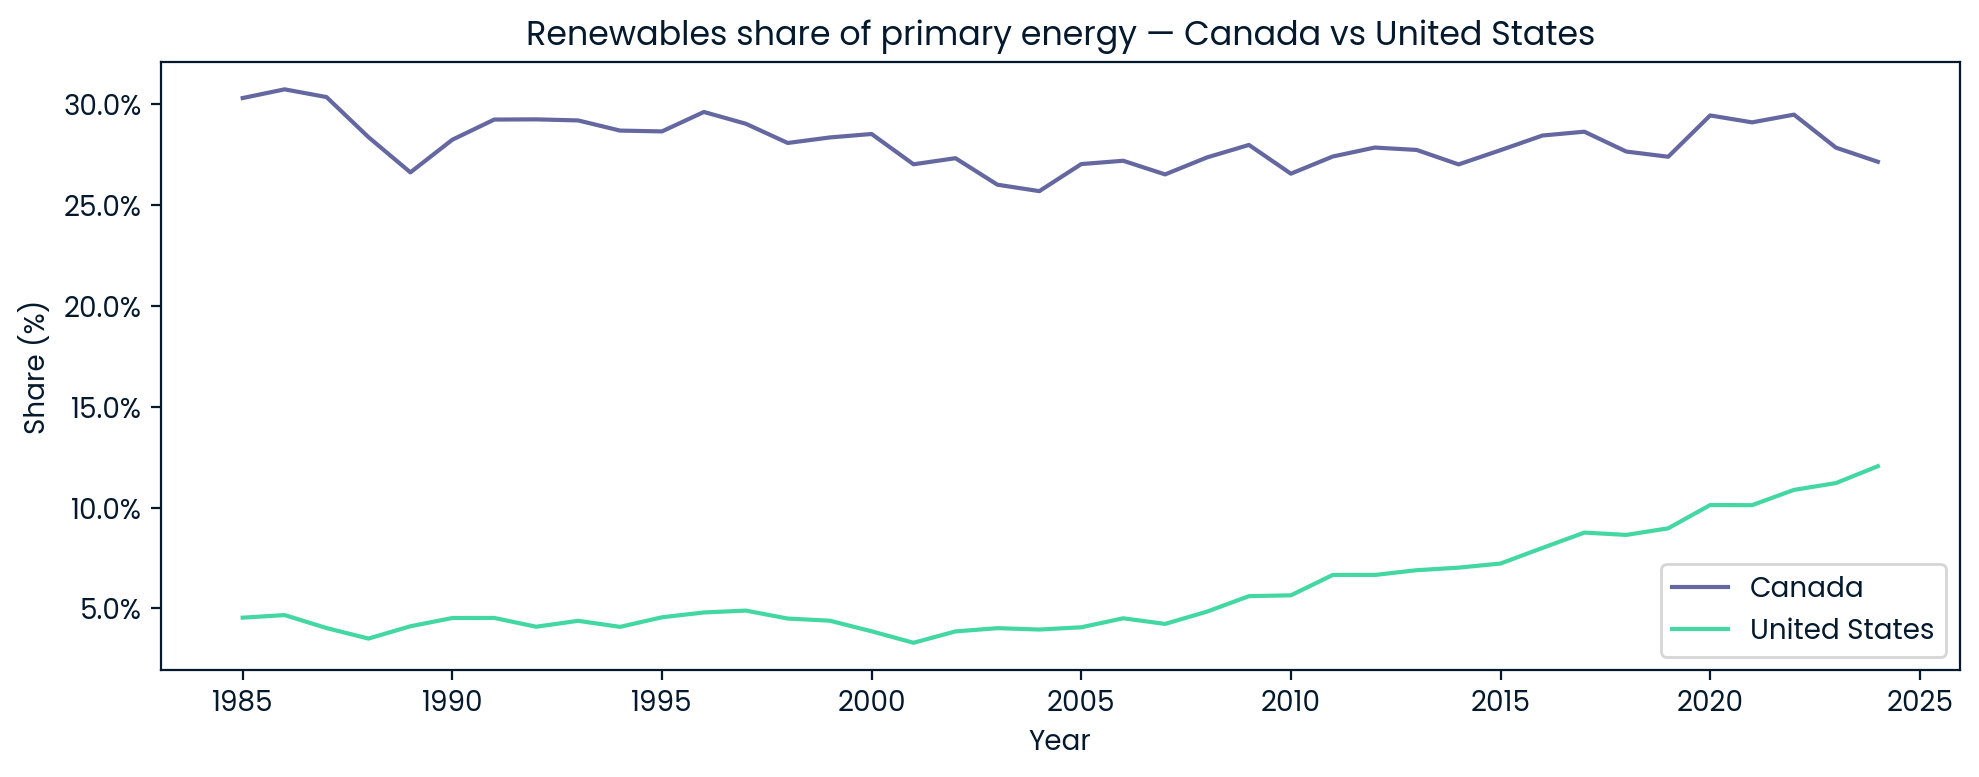

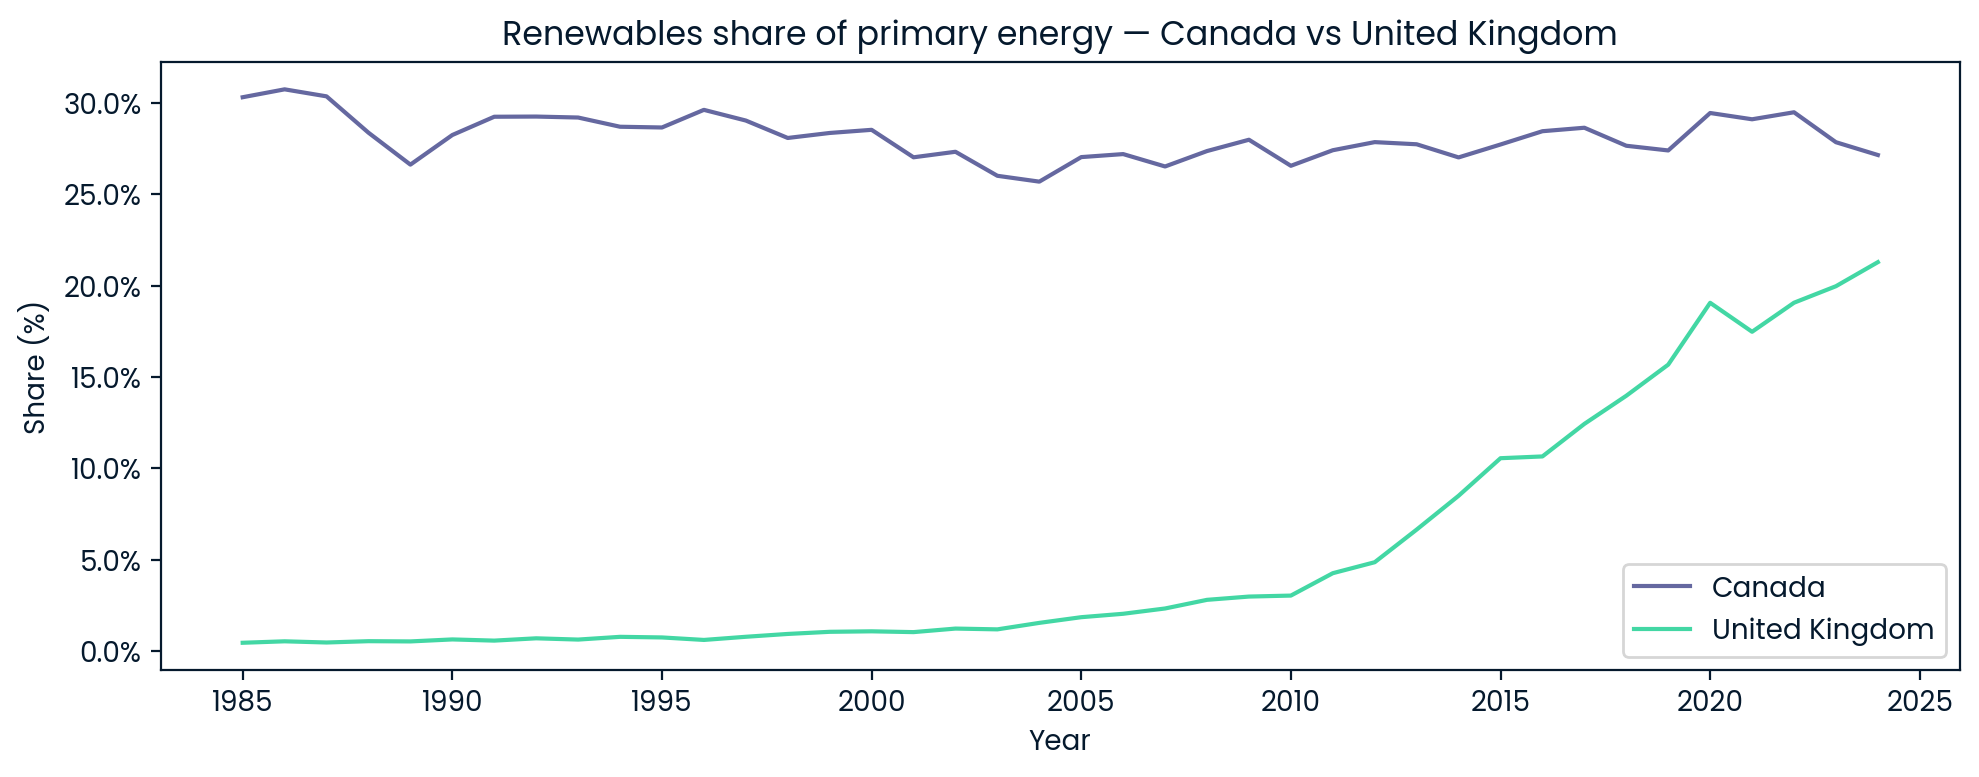

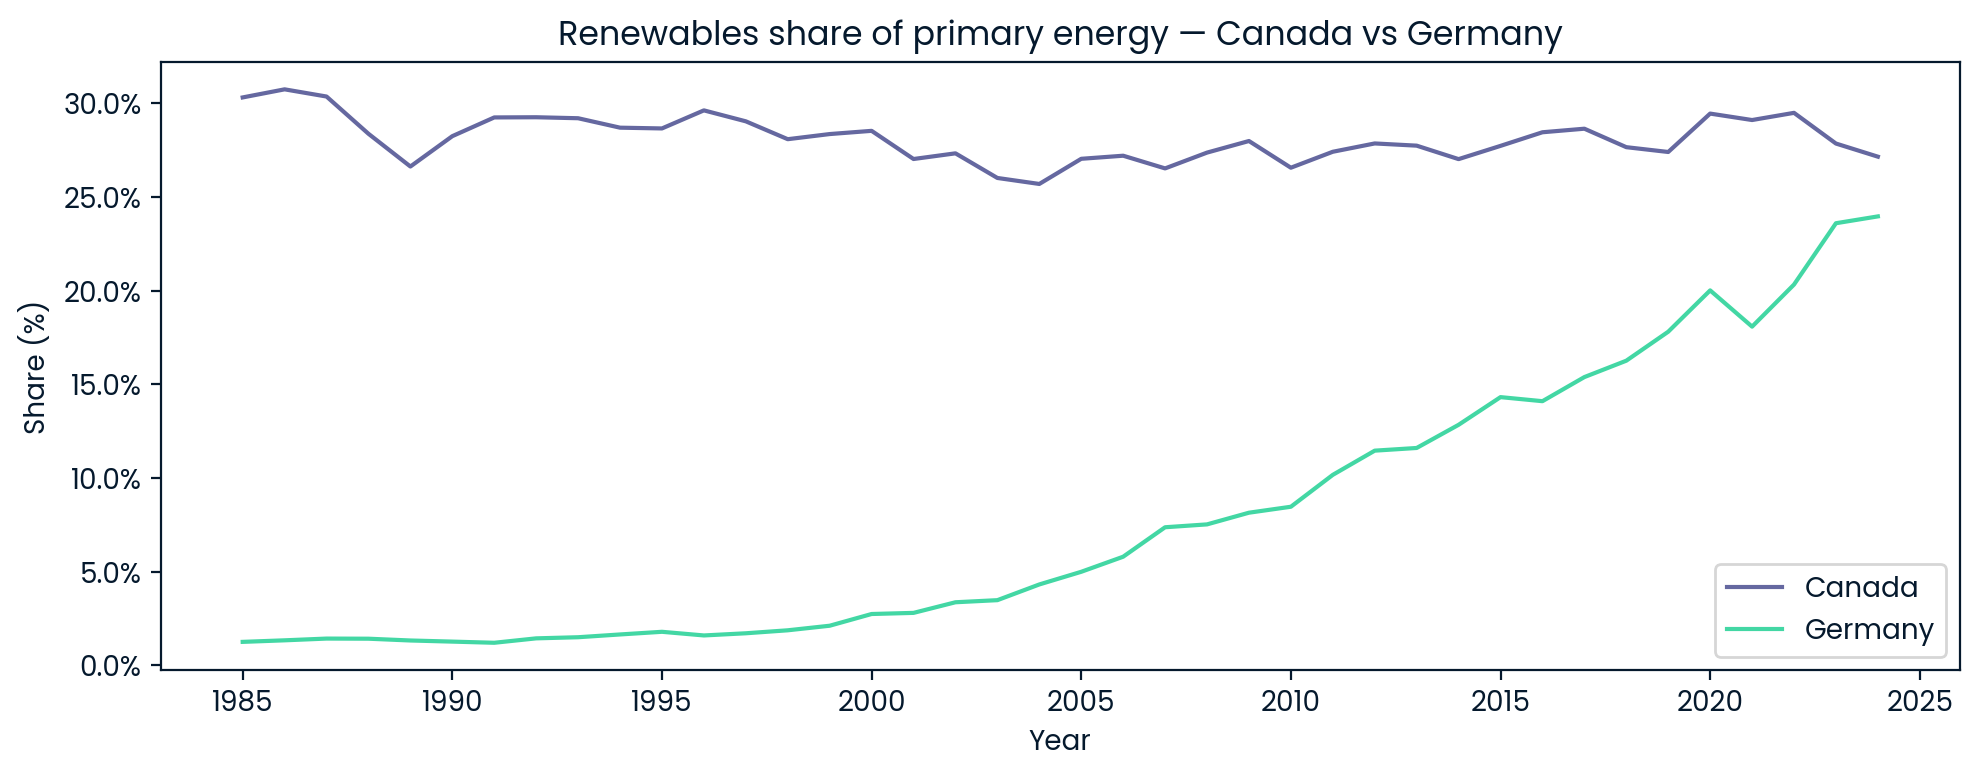

In [33]:
for peer in ["United States", "United Kingdom", "Germany"]:
    d = q6[q6["country"].isin(["Canada", peer])].copy()

    plt.figure(figsize=(10, 4))

    for c in ["Canada", peer]:
        tmp = d[d["country"] == c].sort_values("year")
        plt.plot(tmp["year"], tmp["renewables_share_energy"], label=c)

    plt.title(f"Renewables share of primary energy — Canada vs {peer}")
    plt.xlabel("Year")
    plt.ylabel("Share (%)")
    plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=100))
    plt.legend()
    plt.tight_layout()
    plt.show()

### What the renewables share plots show
- Canada maintains a much higher renewables share of primary energy than the United States across the full period, reflecting a long-standing structural advantage rather than a recent surge. The United Kingdom begins from a very low renewables base but rises rapidly after about 2010, showing one of the fastest transition paths among Canada’s peers. Germany also records a strong long-run increase and closes much of the gap with Canada by 2024. Taken together, these plots suggest that Canada’s advantage lies more in its historically cleaner starting position, while the UK and Germany show faster modern renewables expansion.

### PRIMARY ENERGY STRUCTURE — FOSSIL VS LOW-CARBON SHARES

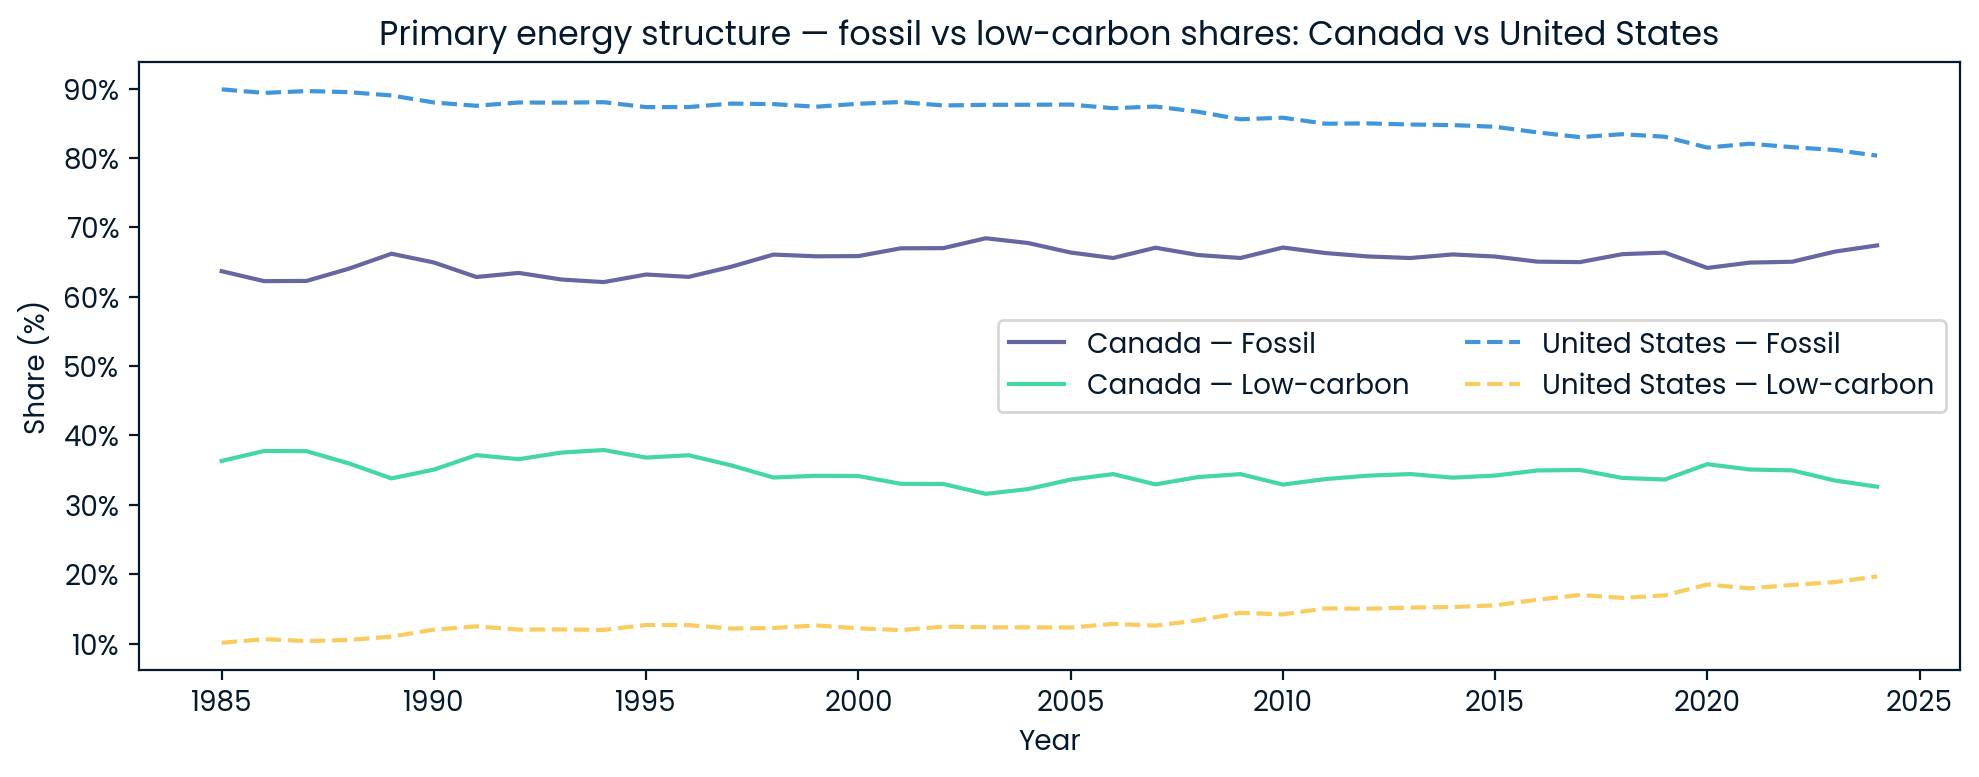

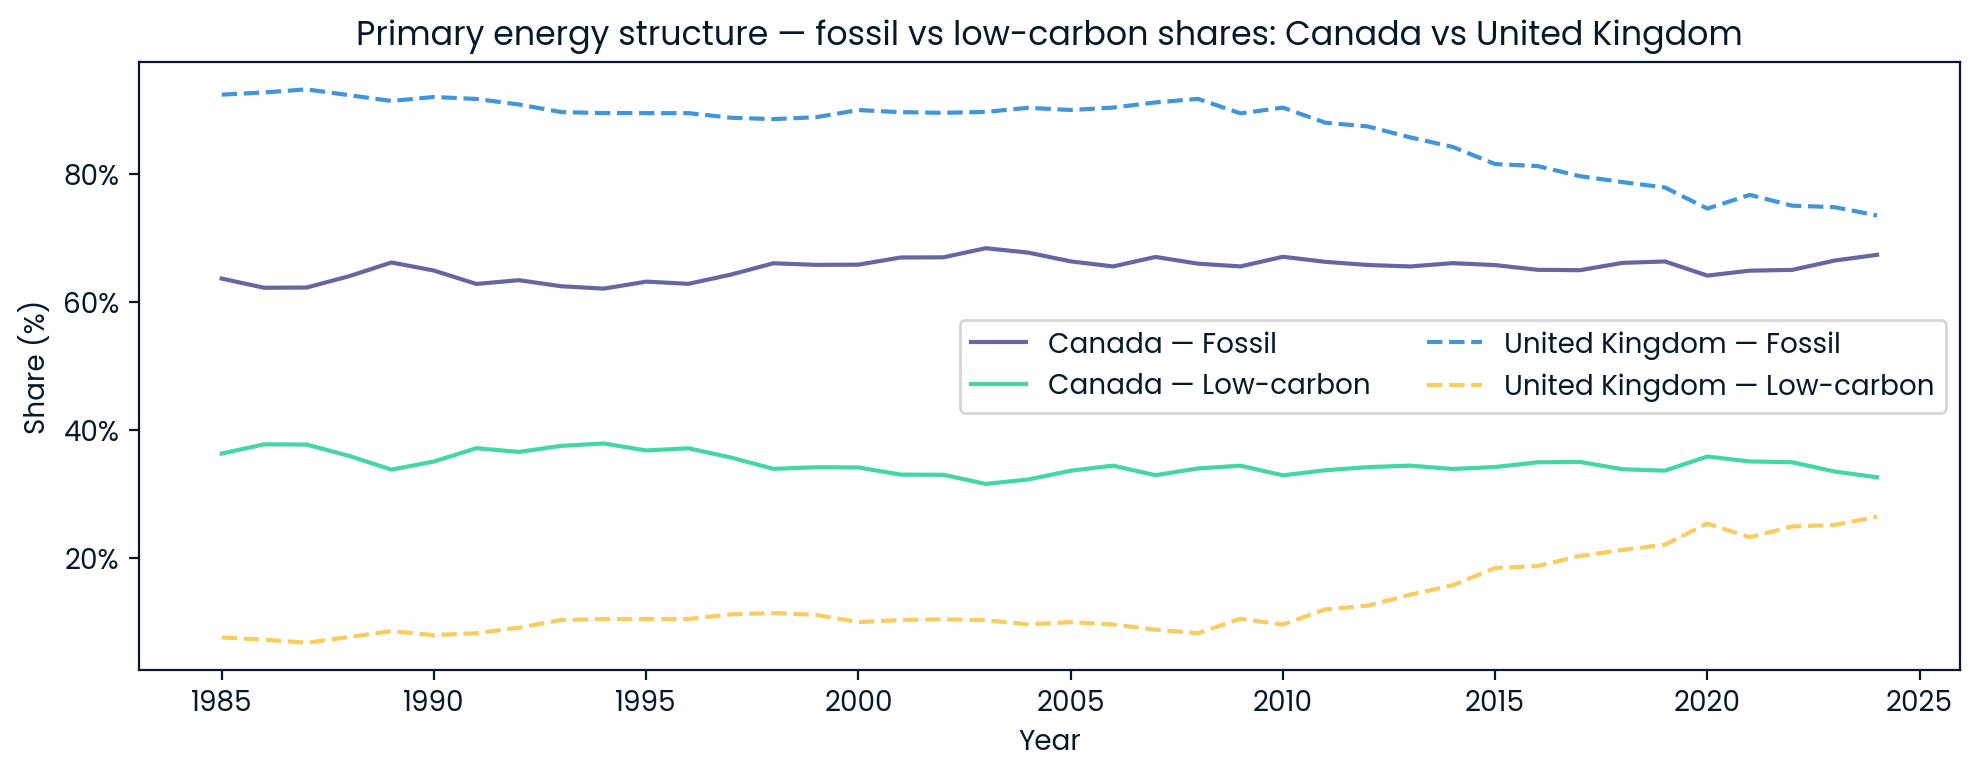

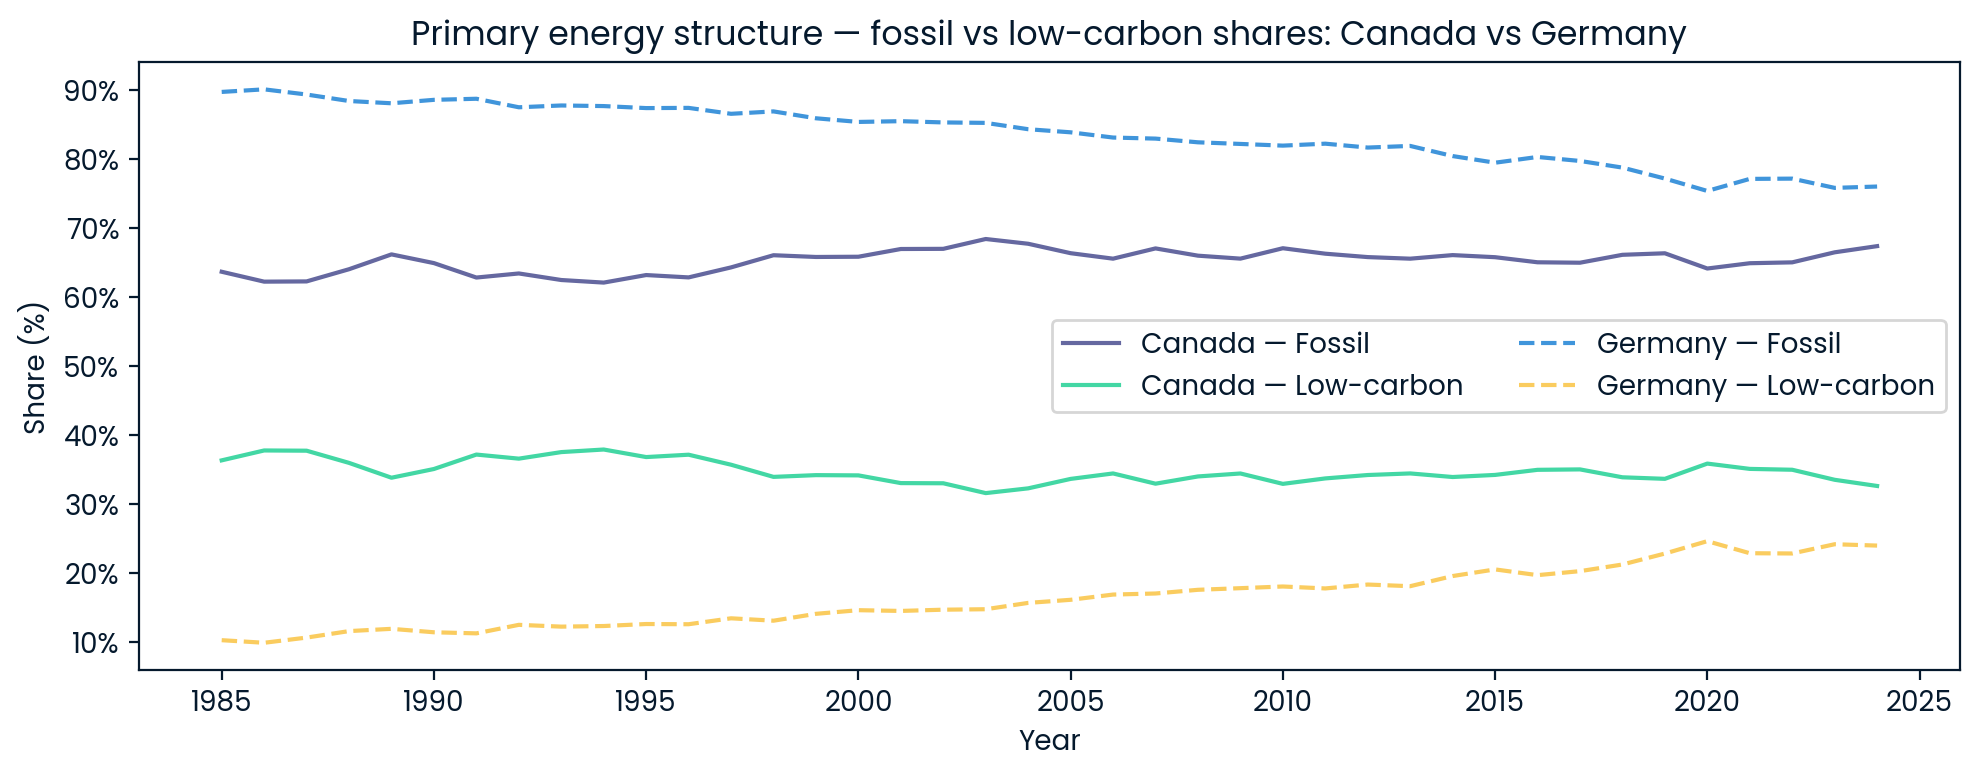

In [34]:
peers = ["United States", "United Kingdom", "Germany"]

for peer in peers:
    d = q6[q6["country"].isin(["Canada", peer])].sort_values("year").copy()

    plt.figure(figsize=(10, 4))

    # Canada
    ca = d[d["country"] == "Canada"]
    plt.plot(ca["year"], ca["fossil_share_energy"], label="Canada — Fossil")
    plt.plot(ca["year"], ca["low_carbon_share_energy"], label="Canada — Low-carbon")

    # Peer
    pr = d[d["country"] == peer]
    plt.plot(pr["year"], pr["fossil_share_energy"], linestyle="--", label=f"{peer} — Fossil")
    plt.plot(pr["year"], pr["low_carbon_share_energy"], linestyle="--", label=f"{peer} — Low-carbon")

    plt.title(f"Primary energy structure — fossil vs low-carbon shares: Canada vs {peer}")
    plt.xlabel("Year")
    plt.ylabel("Share (%)")
    plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=100))
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

### What the fossil vs low-carbon share plots show
- The United States remains more fossil-heavy than Canada throughout the period, even though its low-carbon share rises gradually over time. The United Kingdom and Germany both begin from more fossil-dominant starting points than Canada, but they show clearer long-run rebalancing away from fossil fuels and toward low-carbon energy. Canada, by contrast, begins with a relatively stronger low-carbon baseline, but its overall primary-energy structure changes more slowly. This suggests that Canada’s advantage is mainly structural, while the UK and Germany display stronger transition momentum.

### PRIMARY ENERGY STRUCTURE AT CHECKPOINTS (1985, 2005, 2024)

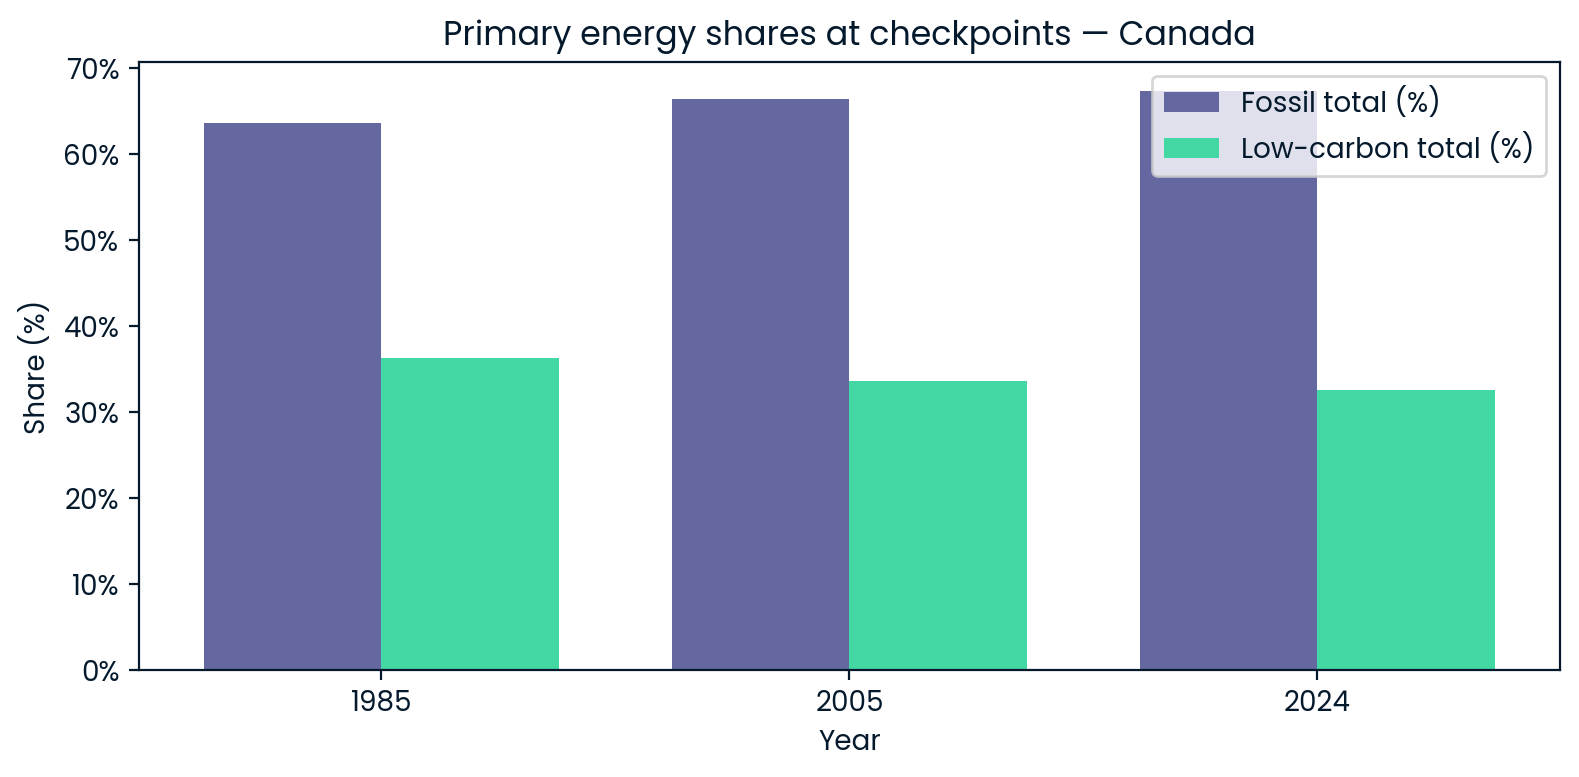

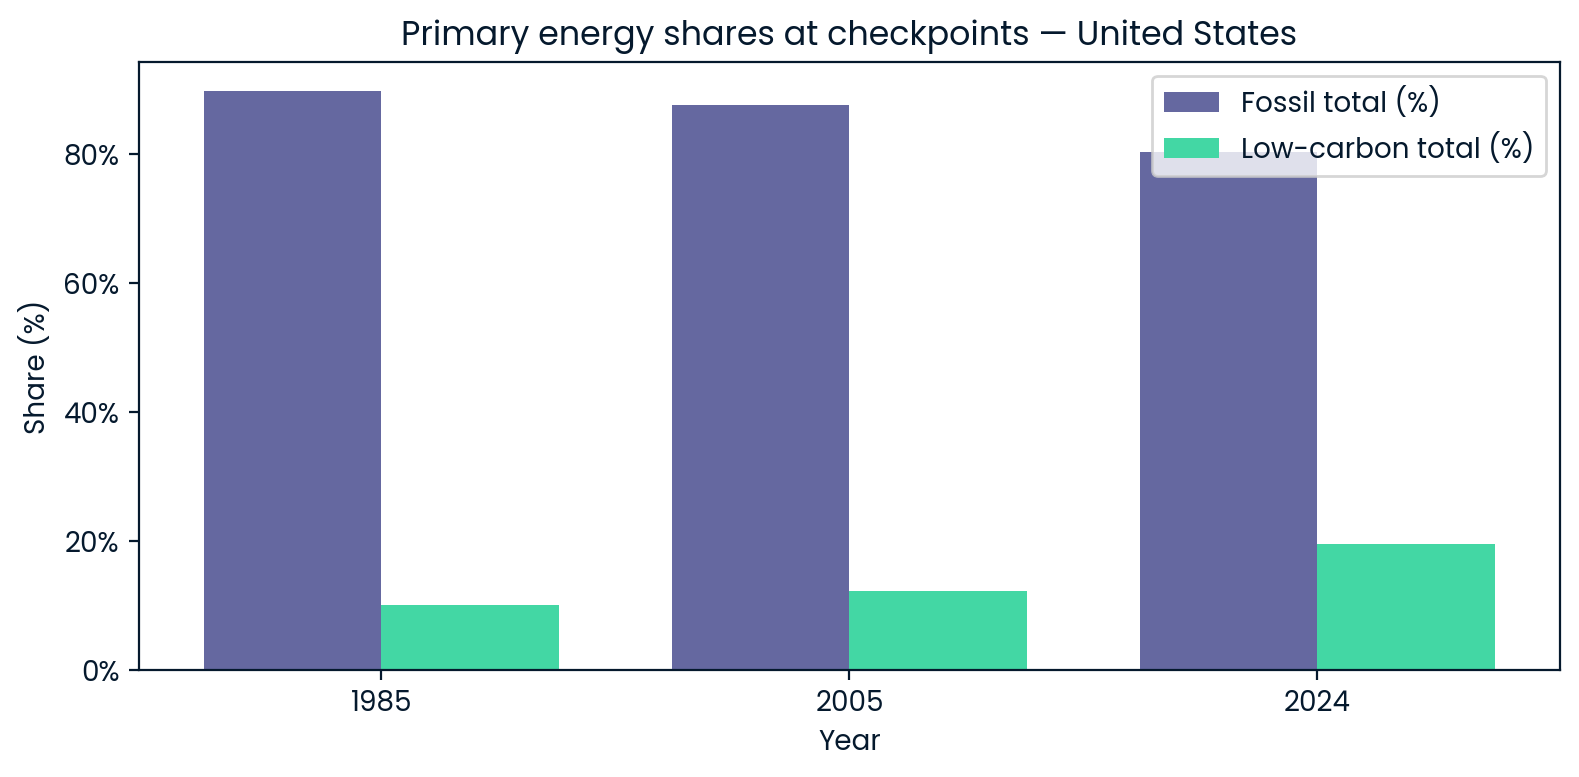

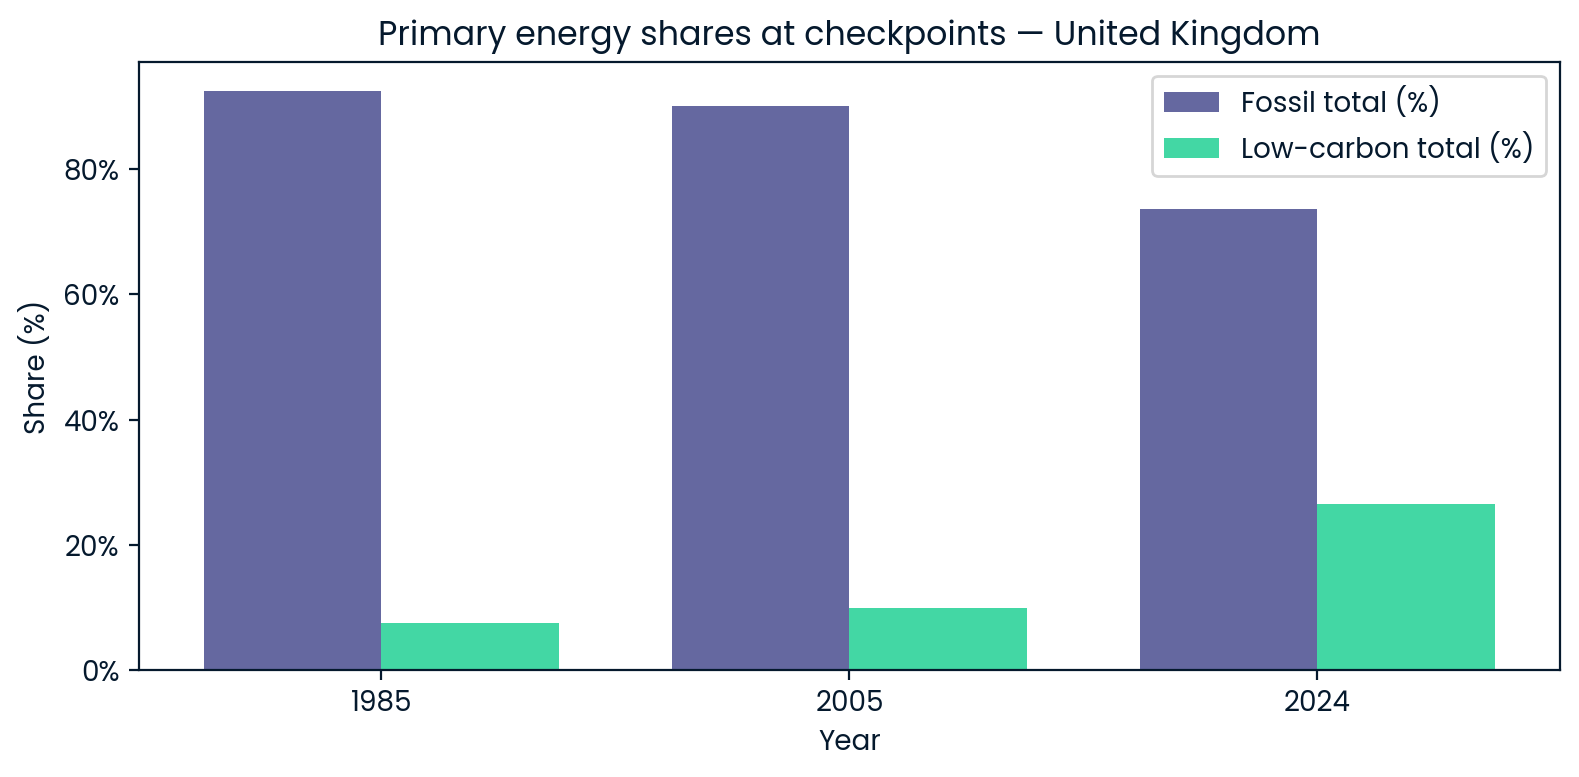

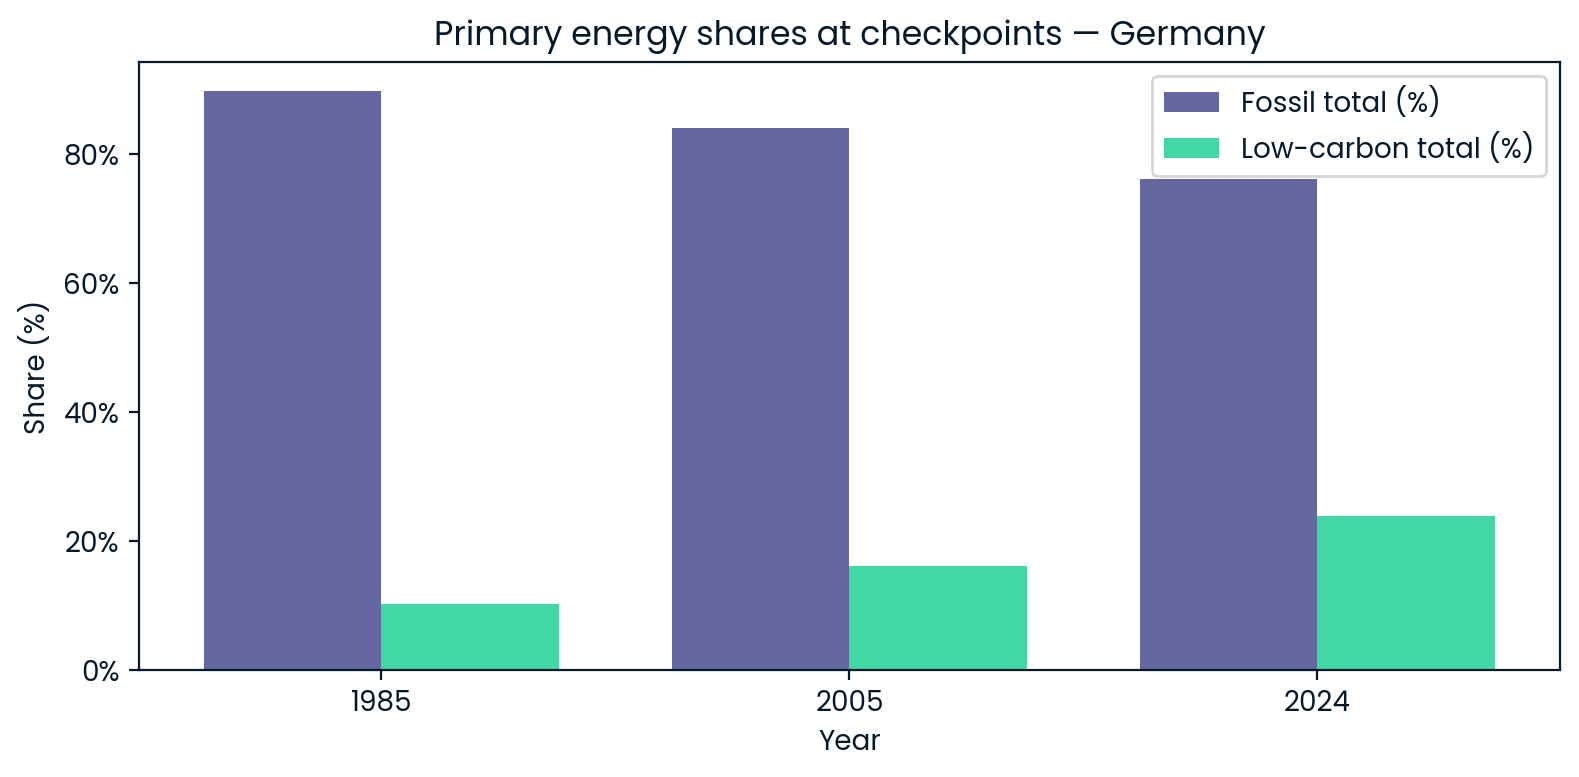

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

for ctry in countries:
    tmp = (
        q6_check_display[q6_check_display["country"] == ctry]
        .sort_values("year")
        .copy()
    )

    x = np.arange(len(tmp["year"]))
    width = 0.38

    plt.figure(figsize=(8, 4))
    plt.bar(x - width/2, tmp["Fossil total (%)"], width=width, label="Fossil total (%)")
    plt.bar(x + width/2, tmp["Low-carbon total (%)"], width=width, label="Low-carbon total (%)")

    plt.title(f"Primary energy shares at checkpoints — {ctry}")
    plt.xlabel("Year")
    plt.ylabel("Share (%)")
    plt.xticks(x, tmp["year"].astype(str))
    plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=100))
    plt.legend()
    plt.tight_layout()
    plt.show()

### What the checkpoint charts show
- The side-by-side checkpoint bars confirm the same structural pattern seen in the line charts. Canada remains fossil-majority across all three benchmark years, with relatively modest change over time, while the United Kingdom and Germany show much larger rebalancing toward low-carbon shares by 2024. The United States also improves, but remains more fossil-heavy than Canada at the end of the period.

### PERCENTAGE-POINT STRUCTURAL CHANGE (2005–2024)

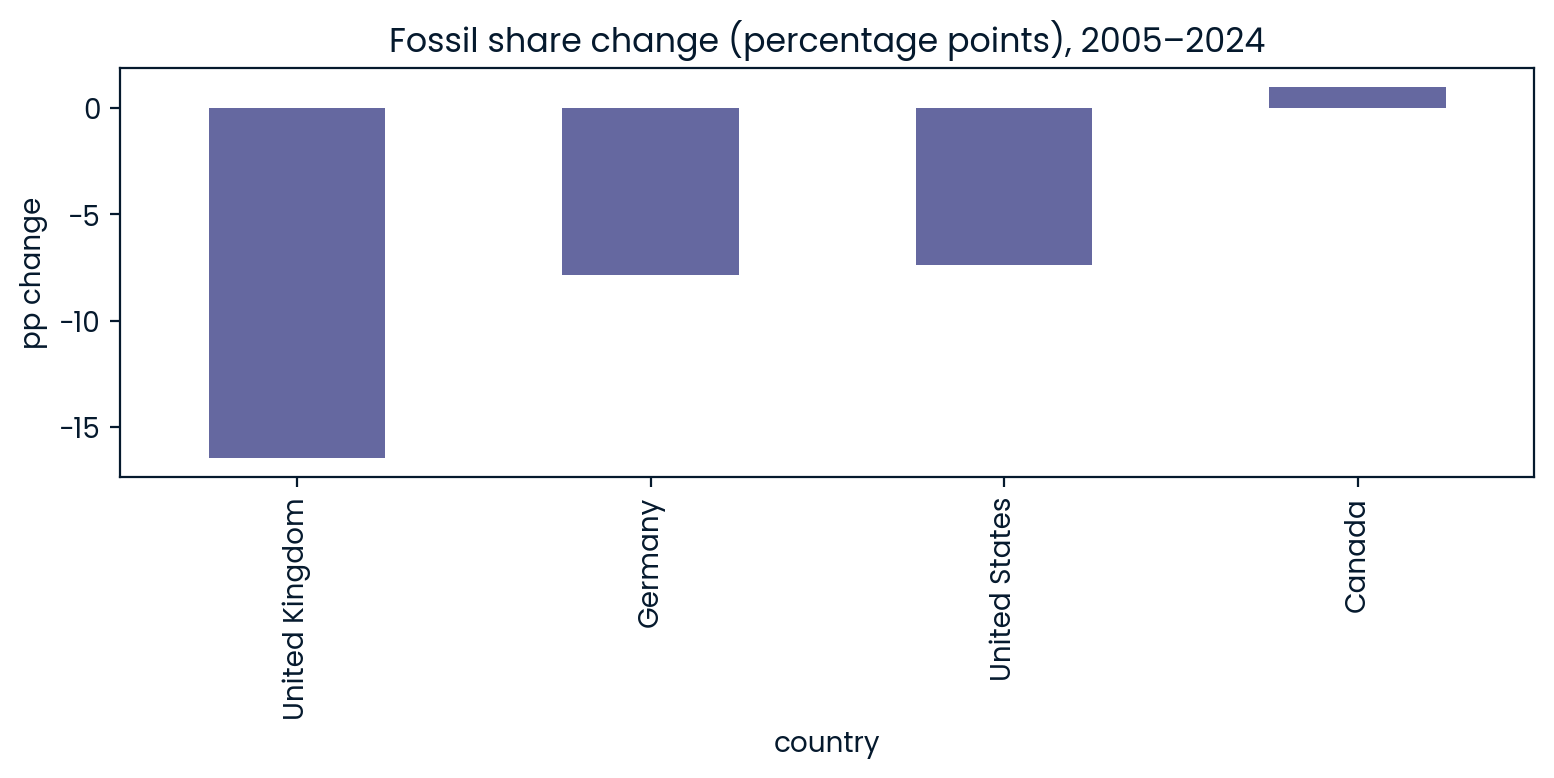

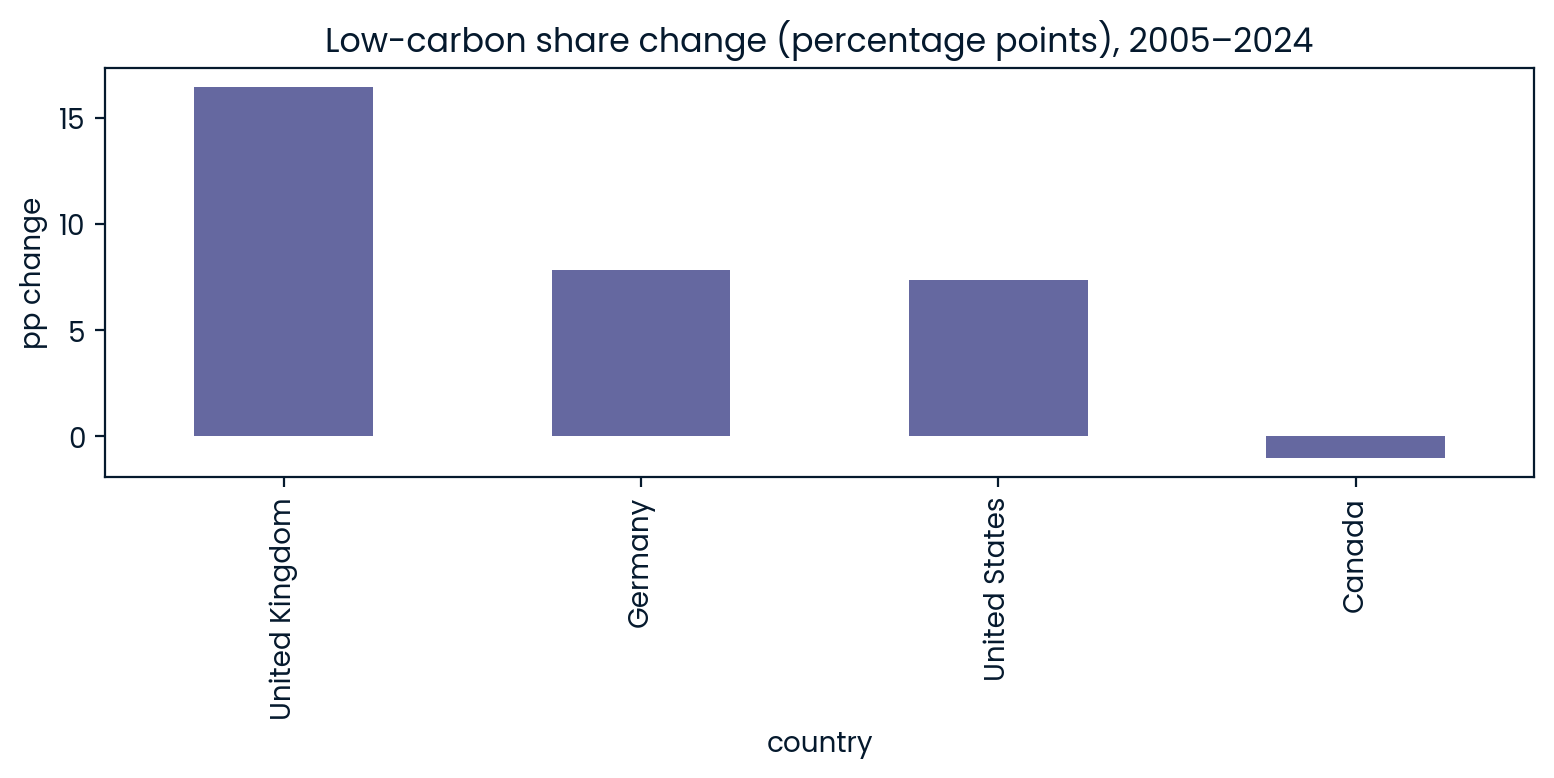

In [36]:
# Build wide tables from checkpoint values
wide_fossil = q6_check_display.pivot(index="country", columns="year", values="Fossil total (%)")
wide_lowcarb = q6_check_display.pivot(index="country", columns="year", values="Low-carbon total (%)")

# Percentage-point change from 2005 to 2024
fossil_pp_2005_2024 = wide_fossil[2024] - wide_fossil[2005]
lowcarb_pp_2005_2024 = wide_lowcarb[2024] - wide_lowcarb[2005]

# Fossil share change
plt.figure(figsize=(8, 4))
fossil_pp_2005_2024.sort_values(ascending=True).plot(kind="bar")
plt.title("Fossil share change (percentage points), 2005–2024")
plt.ylabel("pp change")
plt.tight_layout()
plt.show()

# Low-carbon share change
plt.figure(figsize=(8, 4))
lowcarb_pp_2005_2024.sort_values(ascending=False).plot(kind="bar")
plt.title("Low-carbon share change (percentage points), 2005–2024")
plt.ylabel("pp change")
plt.tight_layout()
plt.show()

### What the percentage-point change charts show
- From 2005 to 2024, the United Kingdom records the strongest structural shift away from fossil fuels and toward low-carbon energy. Germany and the United States also move in the same direction, but with smaller gains. Canada stands out as the outlier: its fossil share changes very little and edges slightly upward, while its low-carbon share declines slightly. This confirms that Canada’s primary-energy transition has been slower than that of its peers, despite its stronger low-carbon starting point.


### CO₂ EMISSIONS PER CAPITA

In [37]:
# loading the OWID CO2 dataset and merging the CO2 per capita into the Q6 dataframe
co2_url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
co2 = pd.read_csv(co2_url)

co2_small = co2[["country", "year", "co2_per_capita"]].copy()
q6 = q6.merge(co2_small, on=["country", "year"], how="left")

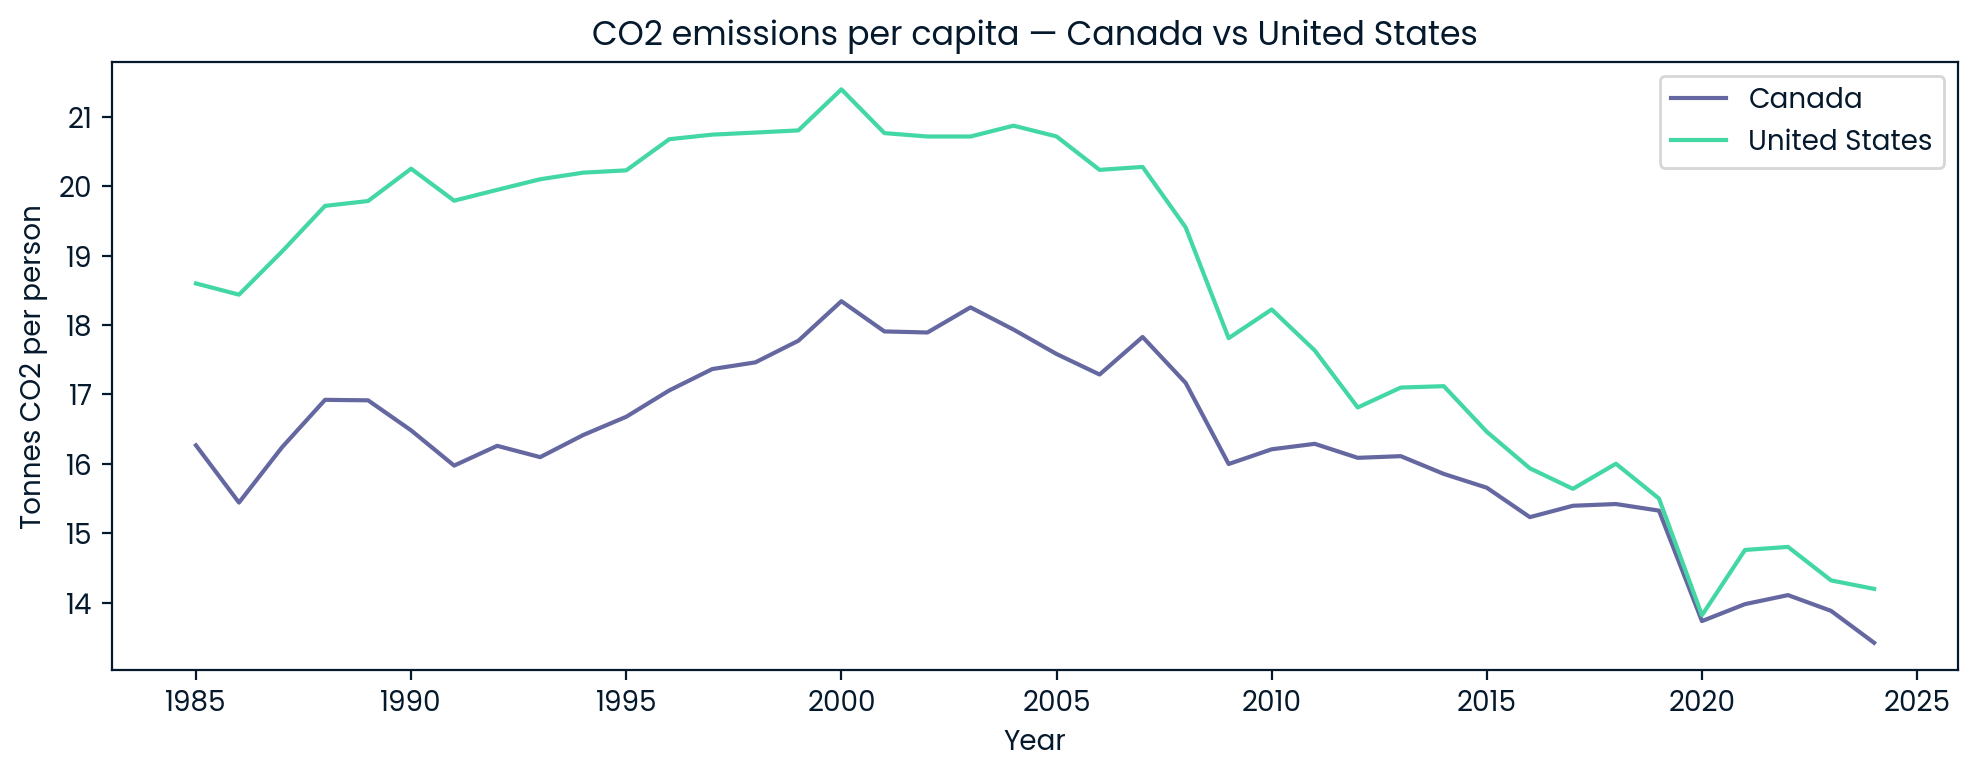

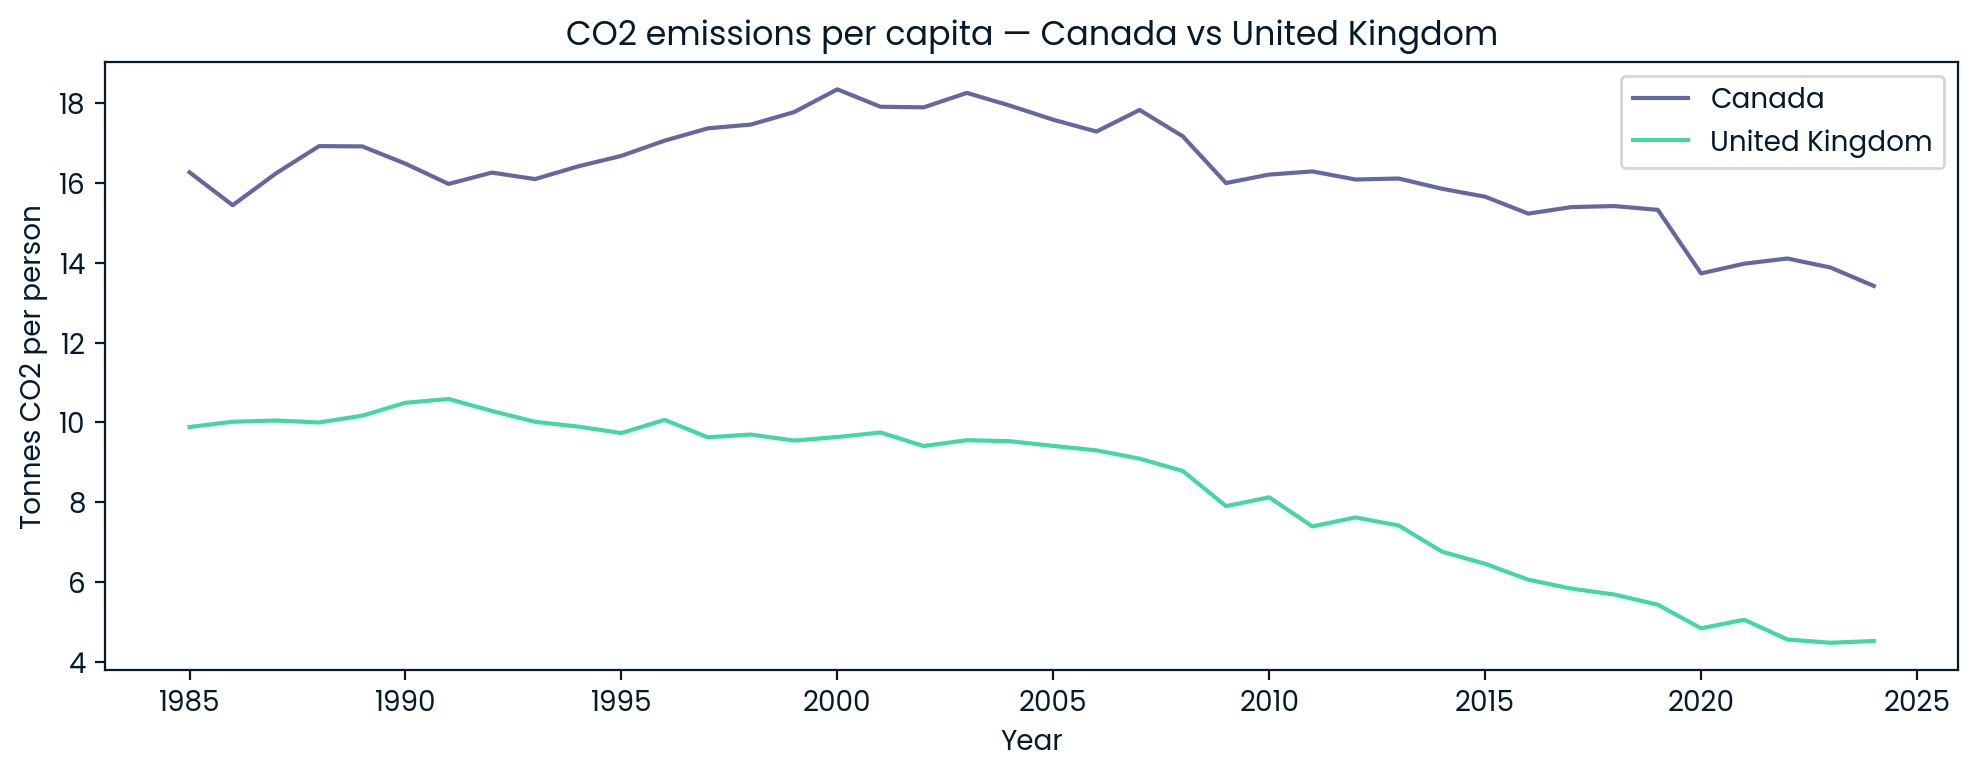

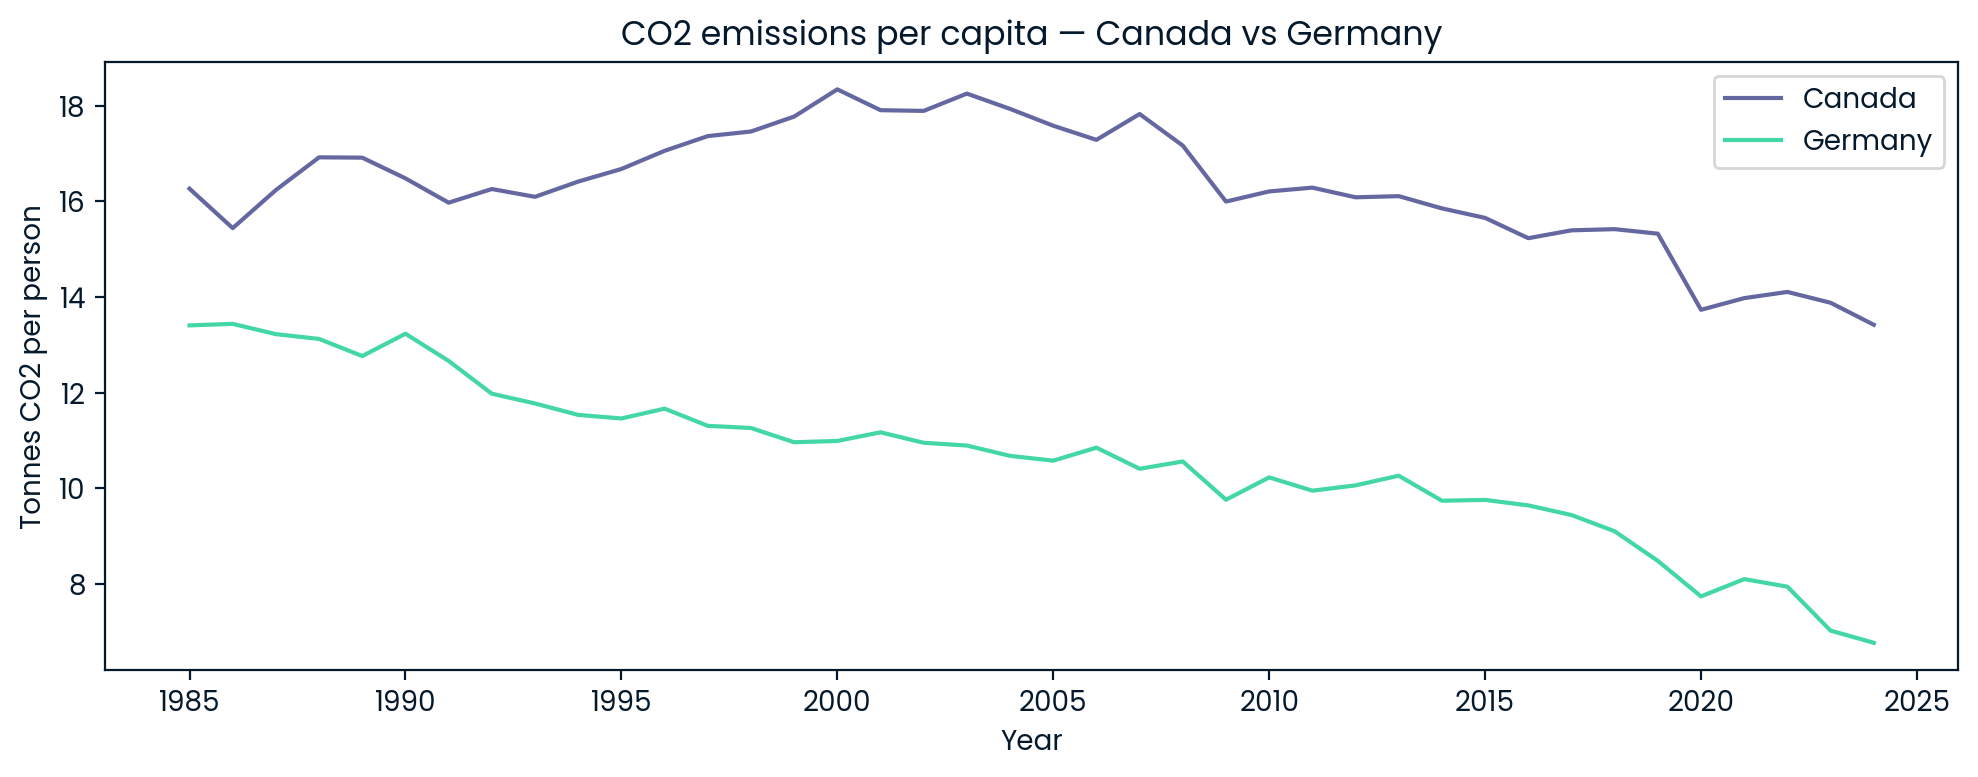

In [38]:
for peer in ["United States", "United Kingdom", "Germany"]:
    d = q6[q6["country"].isin(["Canada", peer])].dropna(subset=["co2_per_capita"]).copy()

    plt.figure(figsize=(10, 4))

    for c in ["Canada", peer]:
        tmp = d[d["country"] == c].sort_values("year")
        plt.plot(tmp["year"], tmp["co2_per_capita"], label=c)

    plt.title(f"CO2 emissions per capita — Canada vs {peer}")
    plt.xlabel("Year")
    plt.ylabel("Tonnes CO2 per person")
    plt.legend()
    plt.tight_layout()
    plt.show()

### What the CO₂ emissions charts show
- Canada’s CO₂ emissions per capita are lower than those of the United States for most of the period, but they remain consistently higher than those of the United Kingdom and Germany. Canada shows a clear decline from its early-2000s peak, yet the gap versus the UK and Germany remains substantial by 2024. This suggests that a relatively stronger low-carbon baseline in primary energy does not automatically translate into lower economy-wide emissions per person. One likely explanation is that Canada still faces substantial fossil-fuel use outside electricity, especially in transport, buildings, and industry.

In other words, Canada performs better than the United States on per-capita emissions, but not as well as the United Kingdom or Germany.

### Q6 KEY TAKEAWAY
Canada enters the peer comparison with a structural advantage: its primary energy mix already contains a larger low-carbon share than those of the United States, the United Kingdom, and Germany. However, Canada’s mix changes more slowly over time, while the UK and Germany show stronger long-run rebalancing away from fossil fuels. The United States remains more fossil-heavy than Canada, but Canada still records much higher CO₂ emissions per capita than the UK and Germany. Taken together, these results suggest that Canada’s challenge appears to be less about building a low-carbon base from scratch and more about reducing fossil dependence in transport, buildings, and industry beyond the electricity system. 

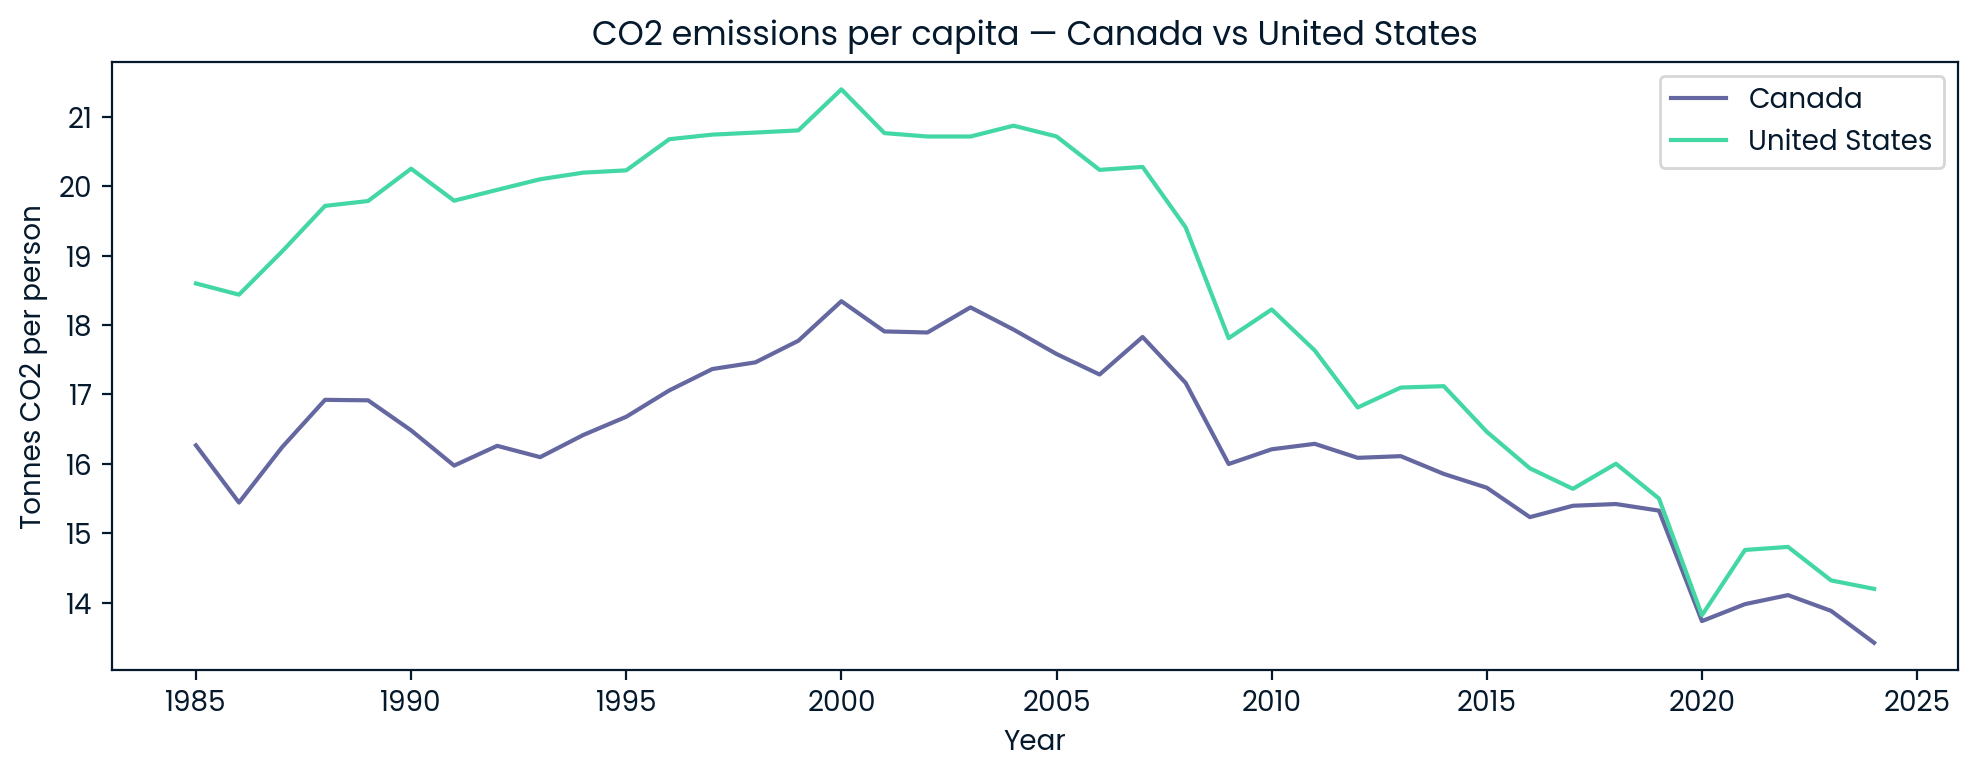

In [39]:
#cell block for importing Q6 image

# Example export pattern for one final figure
d = q6[q6["country"].isin(["Canada", "United States"])].dropna(subset=["co2_per_capita"]).copy()

plt.figure(figsize=(10, 4))
for c in ["Canada", "United States"]:
    tmp = d[d["country"] == c].sort_values("year")
    plt.plot(tmp["year"], tmp["co2_per_capita"], label=c)

plt.title("CO2 emissions per capita — Canada vs United States")
plt.xlabel("Year")
plt.ylabel("Tonnes CO2 per person")
plt.legend()
plt.tight_layout()
plt.savefig("q6_canada_vs_us_co2_per_capita.png", dpi=300, bbox_inches="tight")
plt.show()

# QUESTION 7: Based on historical trends, what energy sources are likely to dominate future growth?

### WHY DOES THIS QUESTION MATTER?
One way to assess likely future growth is to examine which energy sources have gained share most strongly in the most recent period. This section uses recent percentage-point changes as a simple momentum signal. The goal is not to predict the future with certainty, but to identify which technologies appear most likely to drive near-term growth if current transition patterns continue.

### METHOD NOTE

Two recent-change comparisons are used here:

1. **OECD vs Non-OECD electricity mix (2010–2024):** percentage-point changes in selected electricity-source shares.
2. **Canada vs World primary energy (2010–2024):** percentage-point change in renewables’ share of primary energy.

As in Question 4, electricity shares are calculated within the selected tracked source categories, so the results describe tracked-technology mix shifts rather than necessarily the full electricity system.

In [40]:
# ---- A) OECD vs Non-OECD: electricity share changes (2010 -> 2024) ----

start_year, end_year = 2010, 2024

share_cols = ["coal_share", "wind_share", "solar_share"]

elec_delta = elec_mix_trend[
    elec_mix_trend["region_type"].isin(["OECD", "Non-OECD"]) &
    elec_mix_trend["year"].isin([start_year, end_year])
][["region_type", "year"] + share_cols].copy()

wide = elec_delta.pivot(index="region_type", columns="year", values=share_cols)

region_pp_table = (
    wide.xs(end_year, axis=1, level=1) - wide.xs(start_year, axis=1, level=1)
).copy()

region_pp_table = region_pp_table.rename(columns={
    "coal_share": "Coal (pp change)",
    "wind_share": "Wind (pp change)",
    "solar_share": "Solar (pp change)"
})

region_pp_table["Wind+Solar (pp change)"] = (
    region_pp_table["Wind (pp change)"] + region_pp_table["Solar (pp change)"]
)

region_pp_table = (region_pp_table * 100).round(1)
region_pp_table

,Coal (pp change),Wind (pp change),Solar (pp change),Wind+Solar (pp change)
region_type,,,,
Non-OECD,-5.6,6.8,7.0,13.8
OECD,-17.5,8.6,8.1,16.7


This table summarizes how the electricity mix shifted between 2010 and 2024 using percentage-point changes. In both OECD and Non-OECD regions, the clearest growth signal comes from wind and solar, which post the strongest share gains over the period. Coal declines in both groups, but the reduction is steeper in the OECD, indicating faster coal displacement in advanced economies.

The contrast is important. In the OECD, renewables growth is paired with a stronger drop in coal, which suggests a more displacement-driven transition. In Non-OECD regions, wind and solar also expand, but the slower coal decline suggests that low-carbon growth is occurring alongside continued fossil dependence rather than replacing it at the same pace.

In [41]:
# ---- B) Canada vs World: renewables share of primary energy change (2010 -> 2024) ----

start_year, end_year = 2010, 2024

pe_delta = df[
    df["country"].isin(["Canada", "World"]) &
    df["year"].isin([start_year, end_year])
][["country", "year", "renewables_share_energy"]].copy()

wide_pe = pe_delta.pivot(index="country", columns="year", values="renewables_share_energy")

pe_pp_table = (
    wide_pe[end_year] - wide_pe[start_year]
).to_frame("Renewables share (pp change)")

pe_pp_table = pe_pp_table.round(2)
pe_pp_table

,Renewables share (pp change)
country,
Canada,0.59
World,6.45


This table compares the change in renewables’ share of primary energy between Canada and the world from 2010 to 2024. Over this period, the world records a much larger increase than Canada, indicating stronger recent renewables momentum at the global level.

This does not mean Canada lacks renewables. Instead, it suggests that Canada’s overall primary energy structure is changing more slowly. That is consistent with the fact that primary energy includes transport, buildings, and industry—not just electricity—so system-wide decarbonisation can remain gradual even when parts of the power sector are already relatively low-carbon.

### KEY TAKEAWAY

Across both OECD and Non-OECD electricity systems, the strongest recent growth signal comes from **wind and solar**, which show the largest share gains between 2010 and 2024. In the OECD, these gains are accompanied by a much steeper coal decline, suggesting faster displacement of fossil generation. In Non-OECD regions, wind and solar also expand, but fossil dependence remains more persistent.

When the lens shifts from electricity to total primary energy, the transition appears slower and more uneven. The world increases its renewables share of primary energy much more than Canada over the same period, suggesting that future system-wide decarbonisation will depend not only on cleaner power generation, but also on reducing fossil dependence in transport, buildings, and industry.

# QUESTION 8: What policy and infrastructure implications follow from these long-run energy transition trends?

### WHY THIS QUESTION MATTERS
The earlier questions in this project show how energy systems have changed over time, but trend analysis becomes more useful when it is connected to practical system implications. This final section interprets the results through a policy and infrastructure lens, focusing on what the observed patterns suggest about the next stage of the energy transition.

### POLICY AND INFRASTRUCTURE IMPLICATIONS FROM Q1 - Q7

Several implications follow from the results across Questions 1–7.

**1. Power-sector decarbonisation is progressing, but at different speeds across regions.**  
- The OECD shows a faster decline in electricity carbon intensity and a stronger reduction in fossil electricity shares, especially coal. This suggests that sustained policy support, coal retirement, and continued wind and solar deployment can materially lower power-sector emissions. In Non-OECD regions, low-carbon electricity also expands, but fossil generation remains more dominant, implying that future progress will depend not only on adding renewables, but also on addressing coal lock-in, grid constraints, and rapidly growing electricity demand.

**2. Wind and solar appear to be the strongest near-term growth technologies in electricity.**  
- Recent share changes suggest that wind and solar are the clearest sources of incremental electricity growth in both OECD and Non-OECD systems. This points to the importance of transmission expansion, grid flexibility, storage, and interconnection, since higher shares of variable renewables require stronger system-balancing capacity. In other words, generation growth alone is not enough; network and flexibility investments become increasingly important as renewable penetration rises.

**3. A cleaner electricity mix does not automatically produce low economy-wide emissions.**  
- Canada’s peer comparison shows that a relatively stronger low-carbon baseline in primary energy does not automatically translate into lower CO2 emissions per capita. This suggests that decarbonisation beyond electricity remains critical. Progress in transport, buildings, and industry will likely require electrification, efficiency improvements, cleaner fuels, and infrastructure that reduces dependence on direct fossil-fuel use.

**4. Starting position and transition momentum are not the same thing.**  
- Some systems begin with structural advantages, while others change faster from a weaker starting point. Canada, for example, maintains a relatively high renewables share in primary energy, but shows slower recent change than the global average. This implies that policymakers should evaluate both current system structure and rate of change. A cleaner starting point is valuable, but long-run transition success still depends on continued movement rather than historical advantage alone.

**5. Energy transition strategy must be system-wide, not electricity-only.**  
- Across the project, electricity generally shows clearer decarbonisation progress than total primary energy. That difference matters because primary energy captures the broader economy, including transport, heating, and industry. The results therefore suggest that the next phase of transition policy should increasingly focus on sector coupling: cleaner power, wider electrification, demand-side efficiency, and industrial transformation need to move together rather than in isolation.

### KEY TAKEAWAY

Taken together, the results suggest that the energy transition is advancing most clearly in electricity, where wind and solar are emerging as the dominant sources of new growth and coal declines are most visible in OECD systems. However, system-wide decarbonisation remains slower because fossil dependence persists beyond the power sector. The central implication is that future progress will depend not only on building more low-carbon generation, but also on expanding grids, improving flexibility, and reducing fossil-fuel use across transport, buildings, and industry.